# Active Learning Global Optimization of B-Doped Fe/MgO Heterostructures

This script configures and executes an AGOX active learning global optimization search to discover stable structures of a boron-doped iron-on-magnesium oxide ($Fe/MgO$) interface. It automates substrate assembly, introduces compositional variations, and drives a descriptor-based Gaussian Process Regression search coupled with GPAW DFT evaluations.

## Heterostructure Interface Builder 

In [1]:
import os
import re
import numpy as np
from ase import Atoms
from ase.build import bulk, surface
from ase.constraints import FixAtoms
from ase.io import read, write

# Custom project scripts for stacking, structural modification, and plotting
from scripts.build_fe_stack import build_fe_stack
from scripts.build_heteroStruct import build_heteroStruct
from scripts.build_mgo_stack import build_mgo_stack
from scripts.remove_random_atoms_by_species import remove_random_atoms_by_species
from scripts.add_adsorbate_to_hollows import add_adsorbate_to_hollows

# === Core Materials & Crystal Structure Configuration
# Substrate settings
substrate_species = 'MgO'
substrate_crystal_structure = 'rocksalt'
a_substrate = 4.212

# Deposition layer settings
deposition_species = 'Fe'
deposition_crystal_structure = 'bcc'
a_deposition = 2.870190        # Optimized LCAO lattice constant (Å)

# Interfacial geometry & matching parameters
vacuum = 20
dist_z_interface = 0.5         # Experimental initial vertical layer separation (Å)
supercell = (5, 5, 1)          # Lateral simulation slab repetition dimensions

substrate_layer_number = 1     # Total thickness of bottom substrate support (monolayers)
deposition_layer_number = 1    # Total thickness of top deposition film (monolayers)

# Strain interpolation: 0.0 = Pure deposition lattice, 1.0 = Fully coherent with substrate
interpolation_factor = 0
a_substrate_matched = a_substrate / np.sqrt(2)  # Coherent interfacial matching scaling factor
strain = (a_substrate_matched - a_deposition) / a_deposition * 100
a_custom = a_deposition + interpolation_factor * (a_substrate_matched - a_deposition)

# === Composition & Adsorbate Modification
removed_num = 0       # Number of deposition atoms randomly pruned for defects
symbol_add = 'B'      # Adsorbate atomic species to insert into hollow sites
z_height_add = 0      # Vertical coordinate height offset relative to the base layer
num_atoms_add = 25     # Target number of adsorbate atoms to insert

# Run & infrastructure setup
seed = 0
path_result = "0_result"
path_xsf = f"{path_result}/xsf"
os.makedirs(path_xsf, exist_ok=True)

# === Structure Building Execution Pipeline
# --- Base Substrate Layer Definition ---
bulk_substrate = bulk(substrate_species, substrate_crystal_structure, a=a_substrate, cubic=True)
slab_substrate_initial = surface(bulk_substrate, (0, 0, 1), layers=1, vacuum=vacuum)

z_positions = slab_substrate_initial.get_positions()[:, 2]
unique_z = np.unique(np.round(z_positions, 5))

if len(unique_z) >= 2:
    unique_z.sort()
    dist_substrate = unique_z[1] - unique_z[0]
else:
    dist_substrate = 2.106

# --- Thin Film and Heterostructure Assembly ---
bulk_deposition = bulk(deposition_species, deposition_crystal_structure, a=a_custom, cubic=True)
slab_deposition_initial = surface(bulk_deposition, (0, 0, 1), layers=1, vacuum=vacuum)

slab_combined_stack = build_mgo_stack(
    slab_deposition_initial, num_layers=substrate_layer_number, dist_mgo=dist_substrate, 
    vacuum=vacuum, output_path=f"{path_xsf}/slab_combined_stack.xsf", rotate_system=False
)
slab_substrate_base = slab_combined_stack[[atom.symbol != deposition_species for atom in slab_combined_stack]].repeat(supercell)
slab_deposition_base = build_fe_stack(
    slab_deposition_initial, num_layers=deposition_layer_number, vacuum=vacuum, 
    output_path=f"{path_xsf}/slab_deposition.xsf"
).repeat(supercell)

slab_deposition = slab_deposition_base.copy() 
slab_substrate = slab_substrate_base.copy()

# Apply modifications (pruning and hollow-site filling)
slab_deposition = remove_random_atoms_by_species(slab_deposition, deposition_species, removed_num)
slab_deposition = add_adsorbate_to_hollows(
    slab_deposition, symbol=symbol_add, height=z_height_add, 
    num_atoms=num_atoms_add, seed=seed
)

# Output generation files
test_hetero, _, _, _, _ = build_heteroStruct(
    slab_substrate, slab_deposition, output_path=f'{path_xsf}/heteroStruct_final.xsf'
)
write(f'{path_xsf}/deposition_layer_only.xsf', slab_deposition)
write(f'{path_xsf}/test_hetero.xsf', test_hetero)

print(f"Structure generation complete. Output saved to: {path_xsf}/")

2026-07-20 17:08:00,773	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


--> Detected 25 total 4-fold hollow sites available on the Fe25 surface.
Structure generation complete. Output saved to: 0_result/xsf/


## Running

In [2]:
import os
import re
import numpy as np

# ASE (Atomic Simulation Environment) imports
from ase import Atoms
from ase.build import bulk, surface
from ase.constraints import FixAtoms
from ase.io import read, write

# AGOX infrastructure & workflow imports
from agox import AGOX
from agox.environments import Environment
from agox.databases import Database
from agox.helpers import SubprocessGPAW

# AGOX pipeline components
from agox.collectors import ParallelCollector, StandardCollector
from agox.acquisitors import LowerConfidenceBoundAcquisitor
from agox.evaluators import LocalOptimizationEvaluator
from agox.postprocessors import ParallelRelaxPostprocess, RelaxPostprocess
from agox.samplers import FixedSampler, KMeansSampler

# AGOX Candidate Generators
from agox.generators import RattleGenerator # , PermutationGenerator

# AGOX Machine Learning & Surrogate Model imports
from agox.models.GPR import GPR
from agox.models.GPR.kernels import RBF, Noise, Constant as C
from agox.models.GPR.priors import Repulsive
from agox.models.descriptors.fingerprint import Fingerprint

# Custom project modules for structural manipulation
from scripts.build_fe_stack import build_fe_stack
from scripts.build_mgo_stack import build_mgo_stack
from scripts.build_heteroStruct import build_heteroStruct
from scripts.hetero_struct_randomize import HeteroStructRandomize
from scripts.remove_random_atoms_by_species import remove_random_atoms_by_species
from scripts.add_adsorbate_to_hollows import add_adsorbate_to_hollows
from scripts.plot_structure import plot_structure
from scripts.global_permutation_generator import GlobalPermutationGenerator

# =============================================================================
# CORE CONFIGURATION & INTERFACE GEOMETRY
# =============================================================================

# Substrate properties
substrate_species = 'MgO'
substrate_crystal_structure = 'rocksalt'
a_substrate = 4.212
substrate_layer_number = 1

# Deposition film properties
deposition_species = 'Fe'
deposition_crystal_structure = 'bcc'
a_deposition = 2.870190  # Optimized LCAO lattice constant (Å)
deposition_layer_number = 1

# Interface & cell dimensions
vacuum = 20
dist_z_interface = 0.5   # Initial vertical layer separation (Å)
supercell = (5, 5, 1)    # Lateral repetition matrix
ncores = 24              # CPU cores assigned per GPAW instance
kpts = (1, 1, 1)         # Gamma-point Brillouin zone sampling

# Lattice matching & strain calculation
# (0.0 = Pure deposition lattice, 1.0 = Coherent with substrate)
interpolation_factor = 0
a_substrate_matched = a_substrate / np.sqrt(2)
strain = (a_substrate_matched - a_deposition) / a_deposition * 100
a_custom = a_deposition + interpolation_factor * (a_substrate_matched - a_deposition)

# =============================================================================
# AGOX ACTIVE LEARNING HYPERPARAMETERS
# =============================================================================
kappa = 2                               # LCB exploration/exploitation weight
N_iterations = 100                      # Max search iterations
sample_size = 20                        # KMeans clustering pool capacity
confinement_cell_height_multiplyer = 4  # Search space Z-box multiplier

# Generator population strategy per iteration window: [Randomize, Rattle, Permute]
num_candidates = {
    0: [20, 0, 0],    # Stage: Global structure exploration
    10: [10, 5, 5],   # Stage: Mixed search landscape
    25: [0, 10, 10]   # Stage: Fine-tuning local minima near hulls
}

# =============================================================================
# CHEMICAL DEFECTS & ADSORBATE DOPING
# =============================================================================
removed_num = 0       # Number of deposition film atoms to prune for vacancy defects
symbol_add = 'B'      # Dopant/adsorbate atomic species
z_height_add = 0      # Vertical adsorption height offset from the surface plane
num_atoms_add = 7    #25Fe; 21.87%:7; 30.55%:11; 40.47%:17# Number of adsorbate atoms to insert into available hollows

# =============================================================================
# ACTIVE LEARNING EXECUTION LOOP
# =============================================================================
for seed in range(103):
    print(f"\n==================================================")
    print(f"Executing Global Optimization Sequence | Seed: {seed}")
    print(f"==================================================")
    
    # Establish directory routing paths
    path_result = f"seed_{seed}/0_result"
    path_xsf = f"{path_result}/0_xsf"
    path_fig = f"{path_result}/1_fig"
    db_dir = f"seed_{seed}/1_db"
    latt_log = f'{path_result}/latt_log.md'

    for d in [path_xsf, path_fig, db_dir]:
        os.makedirs(d, exist_ok=True)
        
    # Write geometry and strain reports
    with open(latt_log, 'w') as f:
        f.write(f"{a_deposition=}\n{a_substrate=}\n{a_substrate_matched=}\n{strain=:.2f}%\n")
        
    # --- Substrate Slab Construction ---
    bulk_substrate = bulk(substrate_species, substrate_crystal_structure, a=a_substrate, cubic=True)
    slab_substrate_initial = surface(bulk_substrate, (0, 0, 1), layers=1, vacuum=vacuum)

    # Compute vertical layer spacing within the substrate
    z_positions = slab_substrate_initial.get_positions()[:, 2]
    unique_z = np.unique(np.round(z_positions, 5))
    if len(unique_z) >= 2:
        unique_z.sort()
        dist_substrate = unique_z[1] - unique_z[0]
    else:
        dist_substrate = 2.106  # Empirical fallback default
    
    # --- Deposition Slab Construction ---
    bulk_deposition = bulk(deposition_species, deposition_crystal_structure, a=a_custom, cubic=True)
    slab_deposition_initial = surface(bulk_deposition, (0, 0, 1), layers=1, vacuum=vacuum)
    
    # Assemble individual component stacks
    slab_combined_stack = build_mgo_stack(
        slab_deposition_initial, num_layers=substrate_layer_number, dist_mgo=dist_substrate, 
        vacuum=vacuum, output_path=f"{path_xsf}/slab_combined_stack.xsf", rotate_system=False
    )
    slab_substrate_base = slab_combined_stack[[atom.symbol != deposition_species for atom in slab_combined_stack]].repeat(supercell)
    slab_deposition_base = build_fe_stack(
        slab_deposition_initial, num_layers=deposition_layer_number, vacuum=vacuum, 
        output_path=f"{path_xsf}/slab_deposition.xsf"
    ).repeat(supercell)
    
    slab_deposition = slab_deposition_base.copy() 
    slab_substrate = slab_substrate_base.copy()
    
    # --- Structural Mutations (Vacancies & Adsorption) ---
    if removed_num > 0:
        slab_deposition = remove_random_atoms_by_species(slab_deposition, deposition_species, removed_num)

    # Dynamic hollow site detection and addition
    slab_deposition = add_adsorbate_to_hollows(
        slab_deposition, symbol=symbol_add, height=z_height_add, 
        num_atoms=num_atoms_add, seed=seed
    )

    # Write full trial hetero-interface
    test_hetero, _, _, _, _ = build_heteroStruct(
        slab_substrate, slab_deposition, output_path=f'{path_xsf}/heteroStruct.xsf'
    )

    # --- AGOX Search Boundary Setup ---
    slab_substrate.pbc = [True, True, False]
    confinement_corner = np.array([0, 0, slab_substrate.positions[:, 2].max() + dist_z_interface])
    
    # Establish bounding search volumes based on deposition cluster height
    z_pos = slab_deposition.get_positions()[:, 2]
    h_dep = max(z_pos.max() - z_pos.min(), 2.1)
    confinement_cell = slab_deposition.cell.copy()
    confinement_cell[2, 2] = h_dep * confinement_cell_height_multiplyer

    environment = Environment(
        template=slab_substrate,
        symbols=slab_deposition.get_chemical_formula(),
        confinement_cell=confinement_cell,
        confinement_corner=confinement_corner,
        box_constraint_pbc=[True, True, False]
    )
    
    # --- Candidate Generators Setup ---
    n_rattle = len(slab_deposition)
    generators = [
        # Large-scale stochastic structural layout
        HeteroStructRandomize(
            **environment.get_confinement(),
            slab_deposition=slab_deposition,
            hetero_slab_dist=dist_z_interface,
            rattle_amplitude=1.5,
            n_rattle=n_rattle,
            generate_pristine=False,
            write_struct=True,
        ),
        # Local atomic coordinate rattle adjustments
        RattleGenerator(
            **environment.get_confinement(),
            n_rattle=int(n_rattle * 0.5),
            rattle_amplitude=2.3
        ),
        # Discrete elemental permutation swapping
        GlobalPermutationGenerator(
            **environment.get_confinement(),
            max_number_of_swaps=num_atoms_add,
            rattle_strength=0.5,
        )
    ]
    
    # Validate and write out generator baseline states
    try:
        hetero_candidate = generators[0](sampler=None, environment=environment)[0]
        write(f'{path_xsf}/hetero_candidate.xsf', hetero_candidate)
        
        sampler_fixed = FixedSampler(hetero_candidate)
        rattle_candidate = generators[1](sampler_fixed, environment)[0]
        write(f'{path_xsf}/rattle_candidate.xsf', rattle_candidate)
    
        permutation_candidate = generators[2](sampler_fixed, environment)[0]
        write(f'{path_xsf}/permut_candidate.xsf', permutation_candidate)
        
    except Exception as e:
        print(f"--> [ERROR] Candidate generation failed at Seed {seed}: {e}")
    
    # --- Machine Learning Models & Database Storage ---
    database = Database(filename=f"{db_dir}/db_{seed}.db", order=5)
    descriptor = Fingerprint(environment=environment)
    
    # Compound Gaussian Process Regression (GPR) kernel definition
    beta = 0.01
    kernel = C(5000, (1, 1e5)) * (
        C(beta, (beta, beta)) * RBF() + C(1 - beta, (1 - beta, 1 - beta)) * RBF()
    ) + Noise(0.01, (0.01, 0.01))
    
    model = GPR(descriptor=descriptor, kernel=kernel, database=database, prior=Repulsive())
    
    # Candidate acquisition and parallel clustering pool configuration
    sampler_kmeans = KMeansSampler(descriptor=descriptor, database=database, sample_size=sample_size)
    collector = ParallelCollector(
        generators=generators,
        sampler=sampler_kmeans,
        environment=environment,
        num_candidates=num_candidates,
        order=1
    )
    
    # --- Evaluators & Quantum Calculators Setup (GPAW backend) ---
    acquisitor = LowerConfidenceBoundAcquisitor(model=model, kappa=kappa, order=3)
    
    relaxer = ParallelRelaxPostprocess(
        model=acquisitor.get_acquisition_calculator(),
        constraints=environment.get_constraints(),
        optimizer_run_kwargs={"steps": 100},
        start_relax=10,
        order=2
    )
    
    calc = SubprocessGPAW(
        ncores=ncores,
        mode={"name": "lcao"},
        basis="dzp",
        xc="PBE",
        mixer={"backend": "pulay", "beta": 0.05, "nmaxold": 5, "weight": 100},
        convergence={"energy": 1e-4, "density": 1e-3, "eigenstates": 1e-3},
        txt=f"output_seed_{seed}.txt",
        kpts=kpts,
        symmetry='off',
        nbands='nao',
        maxiter=100,
        occupations={"name": "fermi-dirac", "width": 0.05},
        hund=True,
        spinpol=True
    )
    
    evaluator = LocalOptimizationEvaluator(
        calc,
        gets={"get_key": "prioritized_candidates"},
        optimizer_run_kwargs={"fmax": 0.05, "steps": 1},
        constraints=environment.get_constraints(),
        store_trajectory=False,
        order=4
    )
    
    # --- AGOX Engine Orchestration ---
    agox = AGOX(collector, relaxer, acquisitor, evaluator, database, seed=seed)
    
    # To run the core global optimization search loop, uncomment the following line:
    # agox.run(N_iterations=N_iterations)


Executing Global Optimization Sequence | Seed: 0
--> Detected 25 total 4-fold hollow sites available on the Fe25 surface.


╭───────────────────────────── Environment report ─────────────────────────────╮
│ Atoms in search:                                                             │
│     B = 7                                                                    │
│     Fe = 25                                                                  │
│ Template formula: Mg25O25                                                    │
│ Full formula: B7Fe25Mg25O25                                                  │
│ Cell:                                                                        │
│     14.35 0.00 0.00                                                          │
│     0.00 14.35 0.00                                                          │
│     0.00 0.00 20.00                                                          │
│ Periodicity:                                                                 │
│     True True False                                                          │
│ Box constraint: True                                                         │
│ Confinement corner                                                           │
│     0.00 0.00 10.50                                                          │
│ Confinement cell:                                                            │
│     14.35 0.00 0.00                                                          │
│     0.00 14.35 0.00                                                          │
│     0.00 0.00 8.40                                                           │
╰──────────────────────────────────────────────────────────────────────────────╯

[HeteroStructRandomize] Saving generated structures to: generated_structures/run_20260720_173113
GPR: Attaching to database: <agox.databases.database.Database object at 0x14d0981dec50>


2026-07-20 17:31:51,646	INFO worker.py:2012 -- Started a local Ray instance.
/home/asyamsul24/miniconda3/envs/agox_gofee/lib/python3.11/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


Ray Resources
	node:192.168.3.42 = 1.0
	node:__internal_head__ = 1.0
	CPU = 32.0
	object_store_memory = 16000000000.0
	memory = 64000000000.0
Attempt 0: Pool started successfully.
SamplerKMeans: Attaching to database: <agox.databases.database.Database object at 0x14d0981dec50>


...

  Key match: True


Executing Global Optimization Sequence | Seed: 6
--> Detected 25 total 4-fold hollow sites available on the Fe25 surface.


╭───────────────────────────── Environment report ─────────────────────────────╮
│ Atoms in search:                                                             │
│     B = 7                                                                    │
│     Fe = 25                                                                  │
│ Template formula: Mg25O25                                                    │
│ Full formula: B7Fe25Mg25O25                                                  │
│ Cell:                                                                        │
│     14.35 0.00 0.00                                                          │
│     0.00 14.35 0.00                                                          │
│     0.00 0.00 20.00                                                          │
│ Periodicity:                                                                 │
│     True True False                                                          │
│ Box constraint: True                                                         │
│ Confinement corner                                                           │
│     0.00 0.00 10.50                                                          │
│ Confinement cell:                                                            │
│     14.35 0.00 0.00                                                          │
│     0.00 14.35 0.00                                                          │
│     0.00 0.00 8.40                                                           │
╰──────────────────────────────────────────────────────────────────────────────╯

[HeteroStructRandomize] Saving generated structures to: generated_structures/run_20260720_173552


KeyboardInterrupt: 

# Amorph Codes

## Interstitial Alloy Generation Script

This Python script utilizes a custom utility function to insert a specified number of Boron ($\text{B}$) atoms into the interstitial sites of a Platinum ($\text{Pt}$) host unit cell and writes the resulting alloy and host supercell configurations to `.xsf` files using the Atomic Simulation Environment (ASE).

In [49]:
# from scripts.generate_interstitial_alloy import generate_interstitial_alloy
# Define your host unit cell here (e.g., Pt, Pd, Ir, etc.)
# Note: Must be a conventional cubic FCC cell for correct octahedral mapping
my_host_unit = bulk("Pt", crystalstructure="fcc", cubic=True)
# my_host_unit = bulk("Ta", crystalstructure="bcc", cubic=True)

supercell=(1, 1, 1)

# Generate alloy using the external host unit cell
alloy_structure = generate_interstitial_alloy(
    host_unit=my_host_unit,
    interstitial_element="B",
    supercell_dim=supercell,
    lattice_type = "bcc",
    num_to_add=6
)

from ase.io import write
write("alloy_structure.xsf",alloy_structure)
write("my_host_unit.xsf",my_host_unit*supercell)

--- System Generation Summary (BCC) ---
Host Formula (Supercell): Pt4
Supercell Dimensions: 1x1x1
Total Host Atoms: 4
Max Interstitial Sites: 6
Added Interstitials: 6 (Randomly)
Final Chemical Formula: B6Pt4
---------------------------------


## Cell Scale Sweep

This script performs a parameter sweep to identify the optimal unit cell scaling factor required to generate stable Pt-P interstitial alloy structures. It iteratively expands the cell volume, subjecting each iteration to randomized perturbations and atomic swaps via AGOX to verify structural integrity. The process halts automatically once a scale factor is identified where all test trials pass without physical constraint violations, saving the successful parameters to a JSON file for downstream use.

In [4]:
import os
import json
from pathlib import Path
import numpy as np

# ASE Imports
from ase import Atoms
from ase.build import bulk
from ase.io import write

# AGOX Core & Utilities
from agox.environments import Environment
from agox.generators import RattleGenerator
from agox.samplers import FixedSampler

# Custom Scripts
# from scripts.amorph_struct_randomize import AmorphStructRandomize
# from scripts.amorph_permutation import AmorphPermutationGenerator
from scripts.generate_interstitial_alloy import generate_interstitial_alloy

# === CONFIGURATION PARAMETERS ===

# Host Material & Crystal Structure Settings
HOST_ELEMENT = "Pt"
CRYSTAL_STRUCTURE = "fcc"
LATTICE_CONSTANT = 3.30
SUPERCELL_DIM = (3, 3, 3)

# Interstitial Element & Alloy Settings
INTERSTITIAL_ELEMENT = "P"
CONCENTRATION_PERCENT = 20.0  # Desired interstitial concentration (%)

# Cell Volume Scaling Sweep Parameters
SCALE_START = 1.00
SCALE_STEP = 0.01
N_SCALE_LOOP = 1000
N_STRUCTURE_CHECK = 5

# Generator & Perturbation Parameters
MAX_SWAPS = 20
RAND_ATTEMPTS = 1
PERMUT_ATTEMPTS = 10
RATTLE_AMPLITUDE = 1.5
RATTLE_STRENGTH = 1.5  # For permutation generator

# Overlap & Validation Constraints
CHECK_OVERLAP = True
CHECK_COVALENT = False
MIN_DISTANCE_SCALE = 0.85
MAX_DISTANCE_SCALE = 1.15

# Output Settings
OUTPUT_JSON_PATH = "valid_cell_scale.json"

# === INITIALIZE SWEEP VARIABLES ===

valid_scales = []
best_results = []
save_json = {f"{INTERSTITIAL_ELEMENT}_concentration: {CONCENTRATION_PERCENT}%": []}

# === CELL SCALE SWEEP LOOP ===

for scale_idx in range(N_SCALE_LOOP):
    scale_cell = SCALE_START + scale_idx * SCALE_STEP

    # Establish Directory Structures
    path_result = Path(f"0_result/scale_{scale_cell:.4f}")
    path_xsf = path_result / "0_xsf"
    
    path_result.mkdir(parents=True, exist_ok=True)
    path_xsf.mkdir(parents=True, exist_ok=True)

    print("=" * 80)
    print(f"Testing Scale Cell: {scale_cell:.4f}")
    print("=" * 80)

    # === Structure Generation ===
    host_bulk = bulk(HOST_ELEMENT, CRYSTAL_STRUCTURE, a=LATTICE_CONSTANT, cubic=True)
    host_bulk.set_cell(host_bulk.cell * scale_cell, scale_atoms=True)

    # Calculate number of interstitials to insert dynamically
    amount_a = len(host_bulk * SUPERCELL_DIM)
    concentration_decimal = CONCENTRATION_PERCENT / 100.0
    amount_b = (concentration_decimal * amount_a) / (1.0 - concentration_decimal)
    num_to_add = int(round(amount_b))
    
    print(f"-> Host atoms: {amount_a}, Target: {CONCENTRATION_PERCENT}%, Calculated interstitials to add: {num_to_add}")

    alloy_structure = generate_interstitial_alloy(
        host_unit=host_bulk,
        interstitial_element=INTERSTITIAL_ELEMENT,
        supercell_dim=SUPERCELL_DIM,
        lattice_type=CRYSTAL_STRUCTURE,
        num_to_add=num_to_add,
    )

    write("alloy_structure.xsf", alloy_structure)
    write("host_bulk.xsf", host_bulk * SUPERCELL_DIM)

    # === Define AGOX Environment ===
    template = Atoms("", cell=alloy_structure.cell.copy(), pbc=True)
    environment = Environment(
        template=template,
        symbols=alloy_structure.get_chemical_formula(),
        confinement_cell=template.cell.copy(),
        confinement_corner=np.array([0, 0, 0]),
        box_constraint_pbc=[True, True, True],
    )

    # === Initialize Generators ===
    n_rattle = len(alloy_structure)
    generators = [
        AmorphStructRandomize(
            **environment.get_confinement(),
            amorph=alloy_structure,
            write_struct=True,
            write_temp_struct=False,
            rattle_amplitude=RATTLE_AMPLITUDE,
            attempts=RAND_ATTEMPTS,
            n_rattle=n_rattle,
            generate_pristine=False,
            print_result=False,
            check_covalent=CHECK_COVALENT,
        ),
        RattleGenerator(
            **environment.get_confinement(),
            n_rattle=int(n_rattle),
            rattle_amplitude=RATTLE_AMPLITUDE,
        ),
        AmorphPermutationGenerator(
            **environment.get_confinement(),
            max_number_of_swaps=MAX_SWAPS,
            rattle_strength=RATTLE_STRENGTH,
            use_xy_only=False,
            ignore_species=None,
            write_candidates_to_disk=False,
            replace=True,
            attempts=PERMUT_ATTEMPTS,
            check_overlap=CHECK_OVERLAP,
            min_distance_scale=MIN_DISTANCE_SCALE,
            max_distance_scale=MAX_DISTANCE_SCALE,
            print_result=False,
            write_struct=False,
        ),
    ]

    # === Candidate Trial Generation ===
    success_count = 0
    fail_count = 0

    for i in range(N_STRUCTURE_CHECK):
        try:
            # Generate and save amorphous trial
            amorph_candidate = generators[0](sampler=None, environment=environment)[0]
            write(path_xsf / f"amorph_candidate_{i}.xsf", amorph_candidate)
            print(f"amorph {i}")

            sampler_test = FixedSampler(amorph_candidate)

            # Generate and save permutation trial
            permut_candidate = generators[2](sampler_test, environment)[0]
            write(path_xsf / f"permut_candidate_{i}.xsf", permut_candidate)
            print(f"permut {i}")

            success_count += 1

        except Exception as e:
            print(f"Generation failed at trial {i}: {e}")
            fail_count += 1

    # === Process & Record Sweep Iteration Results ===
    best_results.append({
        "scale_cell": scale_cell,
        "success": success_count,
        "fail": fail_count,
    })

    print(f"Result for scale_cell={scale_cell:.4f}: success={success_count}, fail={fail_count}")

    # Stop early if we find a scale configuration that successfully passes all trials
    if fail_count == 0:
        valid_scales.append({
            "scale_cell": scale_cell,
            "success": success_count
        })
        print(f"\n[VALID SCALE FOUND] Stop Sweeping at: {scale_cell:.4f}")
        break

    save_json[f"{INTERSTITIAL_ELEMENT}_concentration: {CONCENTRATION_PERCENT}%"].append({
        "valid_scales": valid_scales
    })

# === WRITE DATA TO JSON ===

with open(OUTPUT_JSON_PATH, "w") as f:
    json.dump(save_json, f, indent=4)

print("=" * 80)
print("Sweep Completed Successfully.")
print(f"Saved Results to: {OUTPUT_JSON_PATH}")

Testing Scale Cell: 1.0000
-> Host atoms: 108, Target: 20.0%, Calculated interstitials to add: 27
--- System Generation Summary (FCC) ---
Host Formula (Supercell): Pt108
Supercell Dimensions: 3x3x3
Total Host Atoms: 108
Max Interstitial Sites: 108
Added Interstitials: 27 (Randomly)
Final Chemical Formula: P27Pt108
---------------------------------


╭───────────────────────────── Environment report ─────────────────────────────╮
│ Atoms in search:                                                             │
│     P = 27                                                                   │
│     Pt = 108                                                                 │
│ Template formula:                                                            │
│ Full formula: P27Pt108                                                       │
│ Cell:                                                                        │
│     9.90 0.00 0.00                                                           │
│     0.00 9.90 0.00                                                           │
│     0.00 0.00 9.90                                                           │
│ Periodicity:                                                                 │
│     True True True                                                           │
│ Box constraint: True                                                         │
│ Confinement corner                                                           │
│     0.00 0.00 0.00                                                           │
│ Confinement cell:                                                            │
│     9.90 0.00 0.00                                                           │
│     0.00 9.90 0.00                                                           │
│     0.00 0.00 9.90                                                           │
╰──────────────────────────────────────────────────────────────────────────────╯

Saved Amorph to: generated_structures/run_20260717_190450
amorph 0
Generation failed at trial 0: list index out of range
amorph 1
Generation failed at trial 1: list index out of range
amorph 2
Generation failed at trial 2: list index out of range
amorph 3
Generation failed at trial 3: list index out of range
amorph 4
Generation failed at trial 4: list index out of range
Result for scale_cell=1.0000: success=0, fail=5
Testing Scale Cell: 1.0100
-> Host atoms: 108, Target: 20.0%, Calculated interstitials to add: 27
--- System Generation Summary (FCC) ---
Host Formula (Supercell): Pt108
Supercell Dimensions: 3x3x3
Total Host Atoms: 108
Max Interstitial Sites: 108
Added Interstitials: 27 (Randomly)
Final Chemical Formula: P27Pt108
---------------------------------


╭───────────────────────────── Environment report ─────────────────────────────╮
│ Atoms in search:                                                             │
│     P = 27                                                                   │
│     Pt = 108                                                                 │
│ Template formula:                                                            │
│ Full formula: P27Pt108                                                       │
│ Cell:                                                                        │
│     10.00 0.00 0.00                                                          │
│     0.00 10.00 0.00                                                          │
│     0.00 0.00 10.00                                                          │
│ Periodicity:                                                                 │
│     True True True                                                           │
│ Box constraint: True                                                         │
│ Confinement corner                                                           │
│     0.00 0.00 0.00                                                           │
│ Confinement cell:                                                            │
│     10.00 0.00 0.00                                                          │
│     0.00 10.00 0.00                                                          │
│     0.00 0.00 10.00                                                          │
╰──────────────────────────────────────────────────────────────────────────────╯

Saved Amorph to: generated_structures/run_20260717_190508
amorph 0
Generation failed at trial 0: list index out of range
amorph 1
Generation failed at trial 1: list index out of range
amorph 2
Generation failed at trial 2: list index out of range
amorph 3
Generation failed at trial 3: list index out of range
amorph 4
Generation failed at trial 4: list index out of range
Result for scale_cell=1.0100: success=0, fail=5
Testing Scale Cell: 1.0200
-> Host atoms: 108, Target: 20.0%, Calculated interstitials to add: 27
--- System Generation Summary (FCC) ---
Host Formula (Supercell): Pt108
Supercell Dimensions: 3x3x3
Total Host Atoms: 108
Max Interstitial Sites: 108
Added Interstitials: 27 (Randomly)
Final Chemical Formula: P27Pt108
---------------------------------


...

╭───────────────────────────── Environment report ─────────────────────────────╮
│ Atoms in search:                                                             │
│     P = 27                                                                   │
│     Pt = 108                                                                 │
│ Template formula:                                                            │
│ Full formula: P27Pt108                                                       │
│ Cell:                                                                        │
│     12.77 0.00 0.00                                                          │
│     0.00 12.77 0.00                                                          │
│     0.00 0.00 12.77                                                          │
│ Periodicity:                                                                 │
│     True True True                                                           │
│ Box constraint: True                                                         │
│ Confinement corner                                                           │
│     0.00 0.00 0.00                                                           │
│ Confinement cell:                                                            │
│     12.77 0.00 0.00                                                          │
│     0.00 12.77 0.00                                                          │
│     0.00 0.00 12.77                                                          │
╰──────────────────────────────────────────────────────────────────────────────╯

Saved Amorph to: generated_structures/run_20260717_191805
amorph 0
Generation failed at trial 0: list index out of range
amorph 1
Generation failed at trial 1: list index out of range
amorph 2
Generation failed at trial 2: list index out of range
amorph 3
Generation failed at trial 3: list index out of range
amorph 4
Generation failed at trial 4: list index out of range
Result for scale_cell=1.2900: success=0, fail=5
Testing Scale Cell: 1.3000
-> Host atoms: 108, Target: 20.0%, Calculated interstitials to add: 27
--- System Generation Summary (FCC) ---
Host Formula (Supercell): Pt108
Supercell Dimensions: 3x3x3
Total Host Atoms: 108
Max Interstitial Sites: 108
Added Interstitials: 27 (Randomly)
Final Chemical Formula: P27Pt108
---------------------------------


╭───────────────────────────── Environment report ─────────────────────────────╮
│ Atoms in search:                                                             │
│     P = 27                                                                   │
│     Pt = 108                                                                 │
│ Template formula:                                                            │
│ Full formula: P27Pt108                                                       │
│ Cell:                                                                        │
│     12.87 0.00 0.00                                                          │
│     0.00 12.87 0.00                                                          │
│     0.00 0.00 12.87                                                          │
│ Periodicity:                                                                 │
│     True True True                                                           │
│ Box constraint: True                                                         │
│ Confinement corner                                                           │
│     0.00 0.00 0.00                                                           │
│ Confinement cell:                                                            │
│     12.87 0.00 0.00                                                          │
│     0.00 12.87 0.00                                                          │
│     0.00 0.00 12.87                                                          │
╰──────────────────────────────────────────────────────────────────────────────╯

Saved Amorph to: generated_structures/run_20260717_191849
amorph 0
Generation failed at trial 0: list index out of range
amorph 1
Generation failed at trial 1: list index out of range


KeyboardInterrupt: 

## AGOX Interstitial Alloy Structure Search Pipeline (Amorph)

This Python script configures and executes a machine learning-accelerated global optimization workflow using the AGOX framework to dynamically generate Platinum-Phosphorus ($\text{Pt-P}$) interstitial alloy candidate structures and optimize them using Gaussian Process Regression (GPR) coupled with GPAW-based Density Functional Theory (DFT) calculations.

In [8]:
import os
from pathlib import Path
import numpy as np

# ASE Imports
from ase import Atoms
from ase.build import bulk
from ase.io import write

# AGOX Core & Utilities
from agox import AGOX
from agox.environments import Environment
from agox.databases import Database
from agox.helpers import SubprocessGPAW

# AGOX Pipeline Components
from agox.generators import RattleGenerator
from agox.samplers import KMeansSampler, FixedSampler
from agox.collectors import ParallelCollector
from agox.acquisitors import LowerConfidenceBoundAcquisitor
from agox.postprocessors import ParallelRelaxPostprocess
from agox.evaluators import LocalOptimizationEvaluator

# AGOX Machine Learning Components
from agox.models.descriptors.fingerprint import Fingerprint
from agox.models.GPR import GPR
from agox.models.GPR.kernels import RBF, Noise, Constant as C
from agox.models.GPR.priors import Repulsive

# Custom Scripts
from scripts.amorph_struct_randomize import AmorphStructRandomize
from scripts.amorph_permutation import AmorphPermutationGenerator
from scripts.generate_interstitial_alloy import generate_interstitial_alloy

# === CONFIGURATION PARAMETERS ===

# Simulation Environment
N_SEEDS = 100
N_ITERATIONS = 100
N_CORES = 1# 24

# Host Material & Crystal Structure Settings
HOST_ELEMENT = "Pt"
CRYSTAL_STRUCTURE = "fcc"
LATTICE_CONSTANT = 3.975534 # optmized
SUPERCELL_DIM = (4, 4, 4)
SCALE_CELL = 1.00  # Cell volume scaling factor

# Interstitial Element & Alloy Settings
INTERSTITIAL_ELEMENT = "P"
CONCENTRATION_PERCENT = 20.0  # Desired interstitial concentration (e.g., 5.0 for 5%)

# Generator & Perturbation Parameters
MAX_SWAPS = 20
PERMUT_ATTEMPTS = 20
CHECK_OVERLAP = False
RAND_ATTEMPTS = 500
CHECK_COVALENT = False
RATTLE_AMPLITUDE = 1.5
RATTLE_STRENGTH = 1.5  # For permutation generator

# AGOX Machine Learning & Sampling Settings
NUM_CANDIDATES = {0: [10, 0, 0], 10: [5, 5, 0], 25: [0, 5, 5]}
SAMPLE_SIZE = 10
BETA = 0.01

# GPAW DFT Calculator Settings
KPTS = (1, 1, 1)
DFT_MODE = {"name": "lcao"}
DFT_BASIS = "dzp"
DFT_XC = "PBE"
DFT_SYMMETRY = "off"
DFT_NBANDS = "nao"
DFT_MIXER = {"backend": "pulay", "beta": 0.05, "nmaxold": 5, "weight": 100}
DFT_CONVERGENCE = {"energy": 1e-4, "density": 1e-3, "eigenstates": 1e-3}
DFT_OCCUPATIONS = {"name": "fermi-dirac", "width": 0.05}
DFT_MAX_ITERATIONS = 100

# Run Stats Tracker
success_count = 0
fail_count = 0

# === SEED ITERATION LOOP ===

for seed in range(N_SEEDS):
    print(f"\n--- Starting Seed: {seed} ---")

    # Establish Directory Structures
    base_dir = Path(f"seed_{seed}")
    path_xsf = base_dir / "0_result" / "0_xsf"
    path_fig = base_dir / "0_result" / "1_fig"
    db_dir = base_dir / "1_db"

    for directory in [path_xsf, path_fig, db_dir]:
        directory.mkdir(parents=True, exist_ok=True)

    # === Structure Generation ===
    host_bulk = bulk(HOST_ELEMENT, CRYSTAL_STRUCTURE, a=LATTICE_CONSTANT, cubic=True)
    host_bulk.set_cell(host_bulk.cell * SCALE_CELL, scale_atoms=True)

    # Calculate number of interstitials to insert dynamically:
    # Formula: B = (C * A) / (1 - C)
    # where:
    #   A = Host atoms (amount_a)
    #   B = Interstitial atoms to add (amount_b)
    #   C = Target concentration in decimal form
    amount_a = len(host_bulk * SUPERCELL_DIM)
    concentration_decimal = CONCENTRATION_PERCENT / 100.0
    amount_b = (concentration_decimal * amount_a) / (1.0 - concentration_decimal)
    
    # We round to the nearest integer to use for our atomic additions
    num_to_add = int(round(amount_b))
    print(f"-> Host atoms: {amount_a}, Target: {CONCENTRATION_PERCENT}%, Calculated interstitials to add: {num_to_add}")

    alloy_structure = generate_interstitial_alloy(
        host_unit=host_bulk,
        interstitial_element=INTERSTITIAL_ELEMENT,
        supercell_dim=SUPERCELL_DIM,
        lattice_type=CRYSTAL_STRUCTURE,
        num_to_add=num_to_add,
    )

    write("alloy_structure.xsf", alloy_structure)
    write("host_bulk.xsf", host_bulk * SUPERCELL_DIM)

    # === Define AGOX Environment ===
    template = Atoms("", cell=alloy_structure.cell.copy(), pbc=True)
    environment = Environment(
        template=template,
        symbols=alloy_structure.get_chemical_formula(),
        confinement_cell=template.cell.copy(),
        confinement_corner=np.array([0, 0, 0]),
        box_constraint_pbc=[True, True, True],
    )

    # === Initialize Generators ===
    n_rattle = len(alloy_structure)
    generators = [
        AmorphStructRandomize(
            **environment.get_confinement(),
            amorph=alloy_structure,
            write_struct=True,
            write_temp_struct=False,
            rattle_amplitude=RATTLE_AMPLITUDE,
            attempts=RAND_ATTEMPTS,
            n_rattle=n_rattle,
            generate_pristine=False,
            print_result=True,
            check_covalent=CHECK_COVALENT,
        ),
        RattleGenerator(
            **environment.get_confinement(),
            n_rattle=int(n_rattle),
            rattle_amplitude=RATTLE_AMPLITUDE,
        ),
        AmorphPermutationGenerator(
            **environment.get_confinement(),
            max_number_of_swaps=MAX_SWAPS,
            rattle_strength=RATTLE_STRENGTH,
            use_xy_only=False,
            ignore_species=None,
            write_candidates_to_disk=False,
            replace=True,
            attempts=PERMUT_ATTEMPTS,
            check_overlap=CHECK_OVERLAP,
            min_distance_scale=0.85,
            max_distance_scale=1.15,
            print_result=False,
            write_struct=False,
        ),
    ]

    # === Generate & Save Dry-Run Candidate Structures ===
    try:
        # Generate Amorphous Candidate
        amorph_candidate = generators[0](sampler=None, environment=environment)[0]
        write(path_xsf / f"amorph_candidate_{seed}.xsf", amorph_candidate)
        print(f"-> Generated amorphous candidate {seed}")

        sampler_test = FixedSampler(amorph_candidate)

        # Generate Rattled Candidate
        rattle_candidate = generators[1](sampler_test, environment)[0]
        write(path_xsf / f"rattle_candidate_{seed}.xsf", rattle_candidate)
        print(f"-> Generated rattled candidate {seed}")

        # Generate Permuted Candidate
        permut_candidate = generators[2](sampler_test, environment)[0]
        write(path_xsf / f"permut_candidate_{seed}.xsf", permut_candidate)
        print(f"-> Generated permuted candidate {seed}")

        success_count += 1
    except Exception as e:
        print(f"-> Failed candidate generation for seed {seed}: {e}")
        fail_count += 1

    print(f"Seed generation status: Successes = {success_count}, Failures = {fail_count}")

    # === Database & Descriptor Setup ===
    database = Database(filename=db_dir / f"db_{seed}.db", order=5)
    descriptor = Fingerprint(environment=environment)

    # === Gaussian Process Regression Model ===
    k0 = C(BETA, (BETA, BETA)) * RBF()
    k1 = C(1 - BETA, (1 - BETA, 1 - BETA)) * RBF()
    kernel = C(5000, (1, 1e5)) * (k0 + k1) + Noise(0.01, (0.01, 0.01))

    model = GPR(
        descriptor=descriptor,
        kernel=kernel,
        database=database,
        prior=Repulsive(),
    )

    # === AGOX Search Components ===
    sampler = KMeansSampler(
        descriptor=descriptor,
        database=database,
        sample_size=SAMPLE_SIZE,
    )

    collector = ParallelCollector(
        generators=generators,
        sampler=sampler,
        environment=environment,
        num_candidates=NUM_CANDIDATES,
        order=1,
    )

    acquisitor = LowerConfidenceBoundAcquisitor(model=model, kappa=2, order=3)

    relaxer = ParallelRelaxPostprocess(
        model=acquisitor.get_acquisition_calculator(),
        constraints=environment.get_constraints(),
        optimizer_run_kwargs={"steps": 100},
        start_relax=10,
        order=2,
    )

    # === GPAW Calculator & Evaluator Setup ===
    calc = SubprocessGPAW(
        ncores=N_CORES,
        mode=DFT_MODE,
        basis=DFT_BASIS,
        xc=DFT_XC,
        kpts=KPTS,
        symmetry=DFT_SYMMETRY,
        nbands=DFT_NBANDS,
        mixer=DFT_MIXER,
        convergence=DFT_CONVERGENCE,
        occupations=DFT_OCCUPATIONS,
        maxiter=DFT_MAX_ITERATIONS,
        txt="output.txt",
    )

    evaluator = LocalOptimizationEvaluator(
        calc,
        gets={"get_key": "prioritized_candidates"},
        optimizer_kwargs={"logfile": None},
        optimizer_run_kwargs={"fmax": 0.05, "steps": 1},
        constraints=environment.get_constraints(),
        order=4,
    )

    # === Run AGOX Optimizer ===
    agox = AGOX(
        collector,
        relaxer,
        acquisitor,
        evaluator,
        database,
        seed=seed,
    )

    # To execute search iterations, uncomment the line below:
    agox.run(N_iterations=N_ITERATIONS)


--- Starting Seed: 0 ---
-> Host atoms: 256, Target: 20.0%, Calculated interstitials to add: 64
--- System Generation Summary (FCC) ---
Host Formula (Supercell): Pt256
Supercell Dimensions: 4x4x4
Total Host Atoms: 256
Max Interstitial Sites: 256
Added Interstitials: 64 (Randomly)
Final Chemical Formula: P64Pt256
---------------------------------


╭───────────────────────────── Environment report ─────────────────────────────╮
│ Atoms in search:                                                             │
│     P = 64                                                                   │
│     Pt = 256                                                                 │
│ Template formula:                                                            │
│ Full formula: P64Pt256                                                       │
│ Cell:                                                                        │
│     15.90 0.00 0.00                                                          │
│     0.00 15.90 0.00                                                          │
│     0.00 0.00 15.90                                                          │
│ Periodicity:                                                                 │
│     True True True                                                           │
│ Box constraint: True                                                         │
│ Confinement corner                                                           │
│     0.00 0.00 0.00                                                           │
│ Confinement cell:                                                            │
│     15.90 0.00 0.00                                                          │
│     0.00 15.90 0.00                                                          │
│     0.00 0.00 15.90                                                          │
╰──────────────────────────────────────────────────────────────────────────────╯

Saved Amorph to: generated_structures/run_20260717_195124
Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/home/asyamsul24/miniconda3/envs/agox_gofee/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3701, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_302344/922407254.py", line 176, in <module>
    amorph_candidate = generators[0](sampler=None, environment=environment)[0]
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/asyamsul24/miniconda3/envs/agox_gofee/lib/python3.11/site-packages/agox/generators/ABC_generator.py", line 186, in __call__
    return self.get_candidates(sampler, environment)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/asyamsul24/miniconda3/envs/agox_gofee/lib/python3.11/site-packages/agox/generators/ABC_generator.py", line 139, in get_candidates
    candidates = self._get_candidates(candidate, parents, environment)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/asyams

## Thermal Volume Expansion Calculator and Plotter

This Python script calculates the volumetric thermal expansion percentage of platinum across a temperature range of 0K to 400K using its linear expansion coefficient, logs the data points to the console, and plots the linear relationship using Matplotlib.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def calculate_platinum_expansion_percent(current_temp_k, initial_temp_k=0):
    """
    Calculates the percentage increment from the original volume.
    Example: 1.0 means a 1% increase over the original baseline.
    """
    alpha = 8.8e-6  # Linear coefficient
    beta = 3 * alpha  # Volumetric coefficient
    
    temp_increase = current_temp_k - initial_temp_k
    
    # Growth percent relative to original: delta_V / V_0 * 100
    percent_increase = (beta * temp_increase) * 100
    return percent_increase

# 1. Generate loop data
temperatures = np.arange(0, 401, 10)
percentages = [calculate_platinum_expansion_percent(t) for t in temperatures]

# Print loop updates to console
for t, p in zip(temperatures, percentages):
    if t % 50 == 0:
        print(f"Temp: {t}K | Volume increased by: {p:.3f}% from original")

# 2. Plot the results
plt.figure(figsize=(8, 5))
plt.plot(temperatures, percentages, color='red', linewidth=2, label='Platinum Growth (%)')

# Chart formatting
plt.title('Platinum Volume Percent Increase (0K to 400K)', fontsize=14)
plt.xlabel('Temperature (K)', fontsize=12)
plt.ylabel('Volume Increase from Original (%)', fontsize=12)

# Format y-axis ticks explicitly as percentages (e.g., 0.20%, 0.40%)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}%'))

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## Calc DFT 

In [4]:
from ase.build import bulk
from gpaw import GPAW, FermiDirac

# 1. Define the lattice constant and create the bulk structure
a_ta = 3.303  # Standard bcc Tantalum lattice constant in Å
ta_bulk = bulk("Ta", "bcc", a=a_ta, cubic=True)

# 2. Define the k-point grid
kpts = (4, 4, 4)

# 3. Initialize GPAW with your parameters
calc = GPAW(
    mode={"name": "lcao"},
    basis="dzp",
    xc="PBE",
    kpts=kpts,
    symmetry="off",
    nbands="nao",
    mixer={"backend": "pulay", "beta": 0.05, "nmaxold": 5, "weight": 100},
    # convergence={"energy": 1e-4, "density": 1e-3, "eigenstates": 1e-3},
    occupations=FermiDirac(width=0.05),
    # maxiter=100,
    txt="ta_bulk.txt"
)

# 4. Attach calculator and run calculation
ta_bulk.calc = calc
total_energy = ta_bulk.get_potential_energy()

# 5. Save the potential energy to a text file
output_filename = "potential_energy.txt"
with open(output_filename, "w") as f:
    f.write(f"Total Potential Energy: {total_energy:.6f} eV\n")

print(f"Calculation complete. Potential energy saved to '{output_filename}'.")

KeyboardInterrupt: 

In [5]:
import os
import numpy as np

from ase import Atoms
from ase.build import bulk
from ase.io import write

from agox.environments import Environment

from scripts.amorph_struct_randomize import AmorphStructRandomize
from scripts.amorph_permutation import AmorphPermutationGenerator
from scripts.add_B_concentration import add_B_concentration

scale_cell = 1.01 
a_ta = 3.30
supercell = (3, 3, 3)
cB = 0.05 

path_result = "single_run/0_result"
path_xsf = f"{path_result}/0_xsf"
os.makedirs(path_xsf, exist_ok=True)

ta_bulk = bulk("Ta", "bcc", a=a_ta, cubic=True) * supercell
ta_bulk.set_cell(ta_bulk.cell * scale_cell, scale_atoms=True)

tab_bulk, n_b, n_ta = add_B_concentration(
    ta_bulk, cB=cB, make_structure=True
)

print(f"{n_b=}")

template = Atoms("", cell=ta_bulk.cell.copy(), pbc=True)
environment = Environment(
    template=template,
    symbols=tab_bulk.get_chemical_formula(),
    confinement_cell=template.cell.copy(),
    confinement_corner=np.array([0, 0, 0]),
    box_constraint_pbc=[True, True, True],
)

write(f"tab_bulk_initial.xsf", tab_bulk)

n_b=3


╭───────────────────────────── Environment report ─────────────────────────────╮
│ Atoms in search:                                                             │
│     B = 3                                                                    │
│     Ta = 54                                                                  │
│ Template formula:                                                            │
│ Full formula: B3Ta54                                                         │
│ Cell:                                                                        │
│     10.00 0.00 0.00                                                          │
│     0.00 10.00 0.00                                                          │
│     0.00 0.00 10.00                                                          │
│ Periodicity:                                                                 │
│     True True True                                                           │
│ Box constraint: True                                                         │
│ Confinement corner                                                           │
│     0.00 0.00 0.00                                                           │
│ Confinement cell:                                                            │
│     10.00 0.00 0.00                                                          │
│     0.00 10.00 0.00                                                          │
│     0.00 0.00 10.00                                                          │
╰──────────────────────────────────────────────────────────────────────────────╯

# MgO on Fe. 5x5. Lattice constraint. 

In [ ]:

import os
import numpy as np

from agox import AGOX
from agox.environments import Environment
from agox.generators import RattleGenerator
from agox.databases import Database
from agox.models.descriptors.fingerprint import Fingerprint
from agox.models.GPR import GPR
from agox.models.GPR.kernels import RBF, Noise, Constant as C
from agox.models.GPR.priors import Repulsive
from agox.samplers import KMeansSampler
from agox.collectors import ParallelCollector, StandardCollector
from agox.acquisitors import LowerConfidenceBoundAcquisitor
from agox.postprocessors import ParallelRelaxPostprocess, RelaxPostprocess
from agox.helpers import SubprocessGPAW
from agox.evaluators import LocalOptimizationEvaluator
from agox.samplers import FixedSampler

from ase import Atoms
from ase.constraints import FixAtoms
from ase.build import surface, bulk
from ase.io import read, write

from scripts.build_mgo_stack import build_mgo_stack
from scripts.build_fe_stack import build_fe_stack
from scripts.hetero_struct_randomize import HeteroStructRandomize
from scripts.plot_structure import plot_structure
from scripts.build_heteroStruct import build_heteroStruct
from scripts.remove_random_atoms_by_species import remove_random_atoms_by_species

# from icecream import ic

vacuum = 20
a_mgo = 4.212
a_fe = 2.866

a_mgo_matched = a_mgo / np.sqrt(2)
strain = (a_mgo_matched - a_fe) / a_fe * 100

"""
Control Strain
0.0 = Fe lattice
1.0 = Fe stretch to fit MgO

Simul: 
0, 0.25, 0.5, 0.75, 1
"""
interpolation_factor = 0
a_custom = a_fe + interpolation_factor * (a_mgo_matched - a_fe)

dist_z_fe2o = 0.5 # experimental: 2.3 A
ncores = 24 #24; 16 cores for genkai
supercell = (5 , 5, 1)
kpts = (1, 1, 1)

kappa=2
N_iterations = 100

mgo_layer_number = 1
fe_layer_number = 1
confinement_cell_height_multiplyer = 4 # multiply env cell height

"""
Concenstration controls. 
Removing atoms.
5x5 1 monolayer is 25 atoms (Fe layer). Remove 25 remove one monolayer.
"""
removed_num = 0 

num_candidates={0:[20,0], 10:[10,10], 25:[0,20]}
sample_size = 20

for seed in range(103):
	print(F"Start seed: {seed}")
	
	path_result = f"seed_{seed}/0_result"
	path_xsf = f"{path_result}/0_xsf"
	path_fig = f"{path_result}/1_fig"
	db_dir = f"seed_{seed}/1_db"
	latt_log = f'{path_result}/latt_log.md'
	
	for d in [path_xsf, path_fig, db_dir]:
		os.makedirs(d, exist_ok=True)
		
	with open(latt_log, 'w') as f:
		f.write(f"{a_fe=}\n{a_mgo=}\n{a_mgo_matched=}\n{strain=:.2f}%\n")
		
	bulk_mgo = bulk('MgO', 'rocksalt', a=a_mgo, cubic=True)
	slab_mgo = surface(bulk_mgo, (0,0,1), layers=1, vacuum=vacuum)
	
	"""
	Calculating distance between MgO layer (Top Mg and bottom O).
	"""
	z_positions = slab_mgo.get_positions()[:, 2]
	unique_z = np.unique(np.round(z_positions, 5))
	
	if len(unique_z) >= 2:
		unique_z.sort()
		dist_mgo = unique_z[1] - unique_z[0]
	
	"""
	Building MgO/Fe(001). Started by making the Fe base (constraint lattice), then put O and Mg on top of it. 
	
	Make MgO(001). We can remove the Fe base.
	Make Fe(001). We multiply the Fe base.
	"""	
	fe_bulk = bulk('Fe', 'bcc', a=a_custom, cubic=True)
	slab_fe_base = surface(fe_bulk, (0, 0, 1), layers=1, vacuum=vacuum)
	
	slab_mgofe = build_mgo_stack(slab_fe_base, num_layers=mgo_layer_number, dist_mgo=dist_mgo, vacuum=vacuum, output_path=f"{path_xsf}/slab_mgofe.xsf")
	slab_mgo = slab_mgofe[[atom.symbol != 'Fe' for atom in slab_mgofe]].repeat(supercell)
	slab_fe = build_fe_stack(slab_fe_base, num_layers=fe_layer_number, vacuum=vacuum, output_path=f"{path_xsf}/slab_fe.xsf").repeat(supercell)
	
	slab_deposition = slab_mgo.copy()
	slab_substrate = slab_fe.copy()
	
	# Consentrations controls
	slab_deposition = remove_random_atoms_by_species(slab_deposition, 'Fe', removed_num)
	
	build_heteroStruct(slab_substrate, slab_deposition, output_path=f'{path_xsf}/heteroStruct.xsf')
	
	slab_substrate.pbc = [True, True, False]
	confinement_corner = np.array([0, 0, slab_substrate.positions[:, 2].max() + dist_z_fe2o])
	
	z_pos = slab_deposition.get_positions()[:, 2]
	h_dep = max(z_pos.max() - z_pos.min(), 2.1)
	confinement_cell = slab_deposition.cell.copy()
	confinement_cell[2, 2] = h_dep * confinement_cell_height_multiplyer
	
	environment = Environment(
		template=slab_substrate,
		symbols=slab_deposition.get_chemical_formula(),
		confinement_cell=confinement_cell,
		confinement_corner=confinement_corner,
		box_constraint_pbc=[True, True, False]
	)
	
	n_rattle = len(slab_deposition)
	generators = [
		HeteroStructRandomize(
			**environment.get_confinement(),
			slab_deposition=slab_deposition,
			hetero_slab_dist=dist_z_fe2o,
			rattle_amplitude=1.5,
			n_rattle=n_rattle,
			generate_pristine=False,
			write_struct=True,
		),
		RattleGenerator(
			**environment.get_confinement(),
			n_rattle=int(n_rattle * 0.5),
			rattle_amplitude=2.3
		),
	]
	
	hetero_candidate = generators[0](sampler=None, environment=environment)[0]
	write(f'{path_xsf}/hetero_candidate.xsf', hetero_candidate)
	
	sampler = FixedSampler(hetero_candidate)
	rattle_candidate = generators[1](sampler, environment)[0]
	write(f'{path_xsf}/rattle_candidate.xsf', rattle_candidate)
	
	database = Database(filename=f"{db_dir}/db_{seed}.db", order=5)
	descriptor = Fingerprint(environment=environment)
	
	beta = 0.01
	kernel = C(5000, (1, 1e5)) * (C(beta, (beta, beta)) * RBF() + C(1-beta, (1-beta, 1-beta)) * RBF()) + Noise(0.01, (0.01, 0.01))
	model = GPR(descriptor=descriptor, kernel=kernel, database=database, prior=Repulsive())
	
	sampler = KMeansSampler(descriptor=descriptor, database=database, sample_size=sample_size)
	collector = ParallelCollector(
		generators=generators,
		sampler=sampler,
		environment=environment,
		num_candidates=num_candidates,
		order=1
	)
	
	acquisitor = LowerConfidenceBoundAcquisitor(model=model, kappa=kappa, order=3)
	
	relaxer = ParallelRelaxPostprocess(
		model=acquisitor.get_acquisition_calculator(),
		constraints=environment.get_constraints(),
		optimizer_run_kwargs={"steps": 100},
		start_relax=10,
		order=2
	)
	
	calc = SubprocessGPAW(
		ncores=ncores,
		mode={"name": "lcao"},
		basis="dzp",
		xc="PBE",
		mixer={"backend": "pulay", "beta": 0.05, "nmaxold": 5, "weight": 100},
		convergence={"energy": 1e-4, "density": 1e-3, "eigenstates": 1e-3},
		txt=f"output_seed_{seed}.txt",
		kpts=kpts,
		symmetry='off',
		nbands='nao',
		maxiter=100,
		occupations={"name": "fermi-dirac", "width": 0.05},
		hund=True,
		spinpol=True
	)
	
	evaluator = LocalOptimizationEvaluator(
		calc,
		gets={"get_key": "prioritized_candidates"},
		optimizer_run_kwargs={"fmax": 0.05, "steps": 1},
		constraints=environment.get_constraints(),
		store_trajectory=False,
		order=4
	)
	
	agox = AGOX(collector, relaxer, acquisitor, evaluator, database, seed=seed)
	agox.run(N_iterations=N_iterations)

# traj filter

In [5]:
from ase.io import read, write

images = read('selected_structures_dos.traj', index=':')

# print(images[4])
indices_to_keep = [0, 4]
filtered_images = [atoms[indices_to_keep] for atoms in images]

write('ref_island.traj', filtered_images)

# Dos

In [ ]:
from gpaw import GPAW, FermiDirac
from ase.io import read
import numpy as np
import pandas as pd
import os

def run_workflow(atoms, seed, kpts=(12, 12, 1), npts=2000, width=0.15):
    calc = GPAW(
        mode={"name": "lcao"},
        basis="dzp",
        xc="PBE",
        mixer={"backend": "pulay", "beta": 0.05, "nmaxold": 5, "weight": 100},
        convergence={"energy": 1e-4, "density": 1e-3},
        txt=f"output_seed_{seed}.txt",
        kpts=kpts,
        symmetry='off',
        nbands='nao',
        maxiter=500,
        occupations={"name": "fermi-dirac", "width": 0.05},
        hund=True,
        spinpol=True
    )

    atoms.calc = calc
    atoms.get_potential_energy()
    
    e_fermi = calc.get_fermi_level()
    emin, emax = -15, 10
    energies_grid = np.linspace(emin, emax, npts)
    
    results = {'energy': energies_grid} 
    
    doscalc = calc.dos()
    spins = range(calc.get_number_of_spins())
    
    total_dos_all_spins = np.zeros(npts)
    for s in spins:
        dos_s = doscalc.raw_dos(energies_grid + e_fermi, spin=s, width=width)
        label = "up" if s == 0 else "down"
        results[f'total_dos_{label}'] = dos_s
        total_dos_all_spins += dos_s
    results['total_dos_sum'] = total_dos_all_spins

    # PDOS for Fe (dz2) and O (pz)
    # Note: In GPAW LCAO PDOS:
    # l=1: p-orbitals (m=0 is pz, m=1 is px, m=2 is py usually, check GPAW basis docs)
    # l=2: d-orbitals (m=2 is dz2)
    symbols = atoms.get_chemical_symbols()
    for i, symbol in enumerate(symbols):
        if symbol == 'Fe':
            for s in spins:
                pdos_val = doscalc.raw_pdos(energies_grid + e_fermi, a=i, l=2, m=2, spin=s, width=width)
                label = "up" if s == 0 else "down"
                results[f'Fe{i}_dz2_{label}'] = pdos_val
                
        elif symbol == 'O':
            for s in spins:
                # m=0 for pz in many spherical harmonic conventions; check specific GPAW version if needed
                pdos_val = doscalc.raw_pdos(energies_grid + e_fermi, a=i, l=1, m=0, spin=s, width=width)
                label = "up" if s == 0 else "down"
                results[f'O{i}_pz_{label}'] = pdos_val

    df = pd.DataFrame(results)
    csv_name = f"dos_seed_{seed}.csv"
    df.to_csv(csv_name, index=False)
    print(f"Analysis for seed {seed} saved to {csv_name}. GPW file discarded.")

from ase.io import write
try:
    structs = read("selected_structures_dos.traj", index=':')
    for i, s in enumerate(structs):
        if i < 3:
            continue
        print(f"{i} ",s)
        write(f"{i}.xsf", s)
        run_workflow(s, seed=i)
except Exception as e:
    print(f"Note: Ensure 'selected_structures_dos_test.traj' exists. Error: {e}")


3  Atoms(symbols='Fe25Mg25O25', pbc=[True, True, False], cell=[14.350000000000001, 14.350000000000001, 20.0], calculator=SinglePointCalculator(...))
4  Atoms(symbols='Fe25Mg25O25', pbc=[True, True, False], cell=[14.35, 14.35, 40.0])


In [1]:
from ase import Atoms
from ase.build import bulk
from ase.io import Trajectory

# Reference BCC Iron lattice constant is ~2.87 Angstroms
lattice_constants = [2.75, 2.80]
traj = Trajectory('selected_structures_dos_test.traj', 'w')

for a in lattice_constants:
    # Create BCC Fe
    atoms = bulk('Fe', 'bcc', a=a)
    
    # Set a magnetic moment since you are using spinpol=True
    # Pure BCC Fe usually has a magnetic moment around 2.22 Bohr magnetons
    atoms.set_initial_magnetic_moments([2.2])
    
    traj.write(atoms)

print("Created selected_structures_dos_test.traj with 5 structures.")

Created selected_structures_dos_test.traj with 5 structures.


In [3]:
from gpaw import GPAW, FermiDirac
from ase.io import read

def run_scf(atoms, seed, kpts=(12, 12, 1)):
    calc = GPAW(
            mode={"name": "lcao"},
            basis="dzp",
            xc="PBE",
            mixer={"backend": "pulay", "beta": 0.05, "nmaxold": 5, "weight": 100},
            # convergence={"energy": 1e-4, "density": 1e-3, "eigenstates": 1e-3},
            convergence={"energy": 1e-0, "density": 1e-0}, # test calc
            txt=f"output_seed_{seed}.txt",
            kpts=kpts,
            symmetry='off',
            nbands='nao',
            maxiter=500,
            occupations={"name": "fermi-dirac", "width": 0.05},
            hund=True,
            spinpol=True
        )

    atoms.calc = calc
    atoms.get_potential_energy()
    # Save the full state: 'mode=all' ensures wavefunctions are kept for PDOS
    calc.write(f"seed_{seed}.gpw", mode='all')
    print(f"SCF complete. Saved seed_{seed}.gpw")

structs = read("selected_structures_dos_test.traj", index=':')
for i, s in enumerate(structs):
    run_scf(s, seed=i)

SCF complete. Saved seed_0.gpw
SCF complete. Saved seed_1.gpw


In [7]:
import numpy as np
import pandas as pd
from gpaw import restart

def run_dos_from_file(seed, npts=2000, width=0.15):
    """
    Calculates DOS and PDOS using the modern GPAW DOS-calculator API.
    """
    # 1. Load atoms and calculator
    atoms, calc = restart(f"seed_{seed}.gpw", txt=None)
    e_fermi = calc.get_fermi_level()
    
    # Define energy grid (eV)
    # The API usually expects energies relative to the average potential, 
    # but we will shift it to be relative to E_f in the final output.
    emin, emax = -15, 10
    energies_grid = np.linspace(emin, emax, npts)
    
    # Initialize storage
    results = {f'energy_{seed}': energies_grid} 

    # 2. Get the DOS Calculator from the GPAW object
    # Note: Modern GPAW documentation suggests using calc.dos() 
    # which returns a DOSCalculator instance.
    doscalc = calc.dos()

    # 3. Total DOS
    # raw_dos takes energies in eV. We pass absolute energies (grid + fermi).
    spins = range(calc.get_number_of_spins())
    total_dos_acc = np.zeros(npts)
    
    for s in spins:
        dos_s = doscalc.raw_dos(energies_grid + e_fermi, spin=s, width=width)
        results[f'spin_{"up" if s==0 else "down"}_{seed}'] = dos_s
        total_dos_acc += dos_s
        
    results[f'total_dos_{seed}'] = total_dos_acc

    # 4. Atomic Orbital PDOS (dz2)
    # Parameters from documentation: l=2 (d-orbitals), m=2 (3z2-r2)
    symbols = atoms.get_chemical_symbols()
    for i, symbol in enumerate(symbols):
        if symbol in ['Fe', 'Ni', 'Co', 'Mo', 'Cr']:
            for s in spins:
                # raw_pdos handles the projection and smearing in one step
                pdos_dz2 = doscalc.raw_pdos(
                    energies_grid + e_fermi, 
                    a=i,      # Atom index
                    l=2,      # d-orbital
                    m=2,      # dz2 orbital
                    spin=s, 
                    width=width
                )
                
                label = "up" if s == 0 else "down"
                results[f'dz2_atom{i}_{symbol}_{label}_{seed}'] = pdos_dz2

    return results

results_seed_0 = run_dos_from_file(seed=1)
df = pd.DataFrame(results_seed_0)
df.to_csv("dos_analysis.csv", index=False)

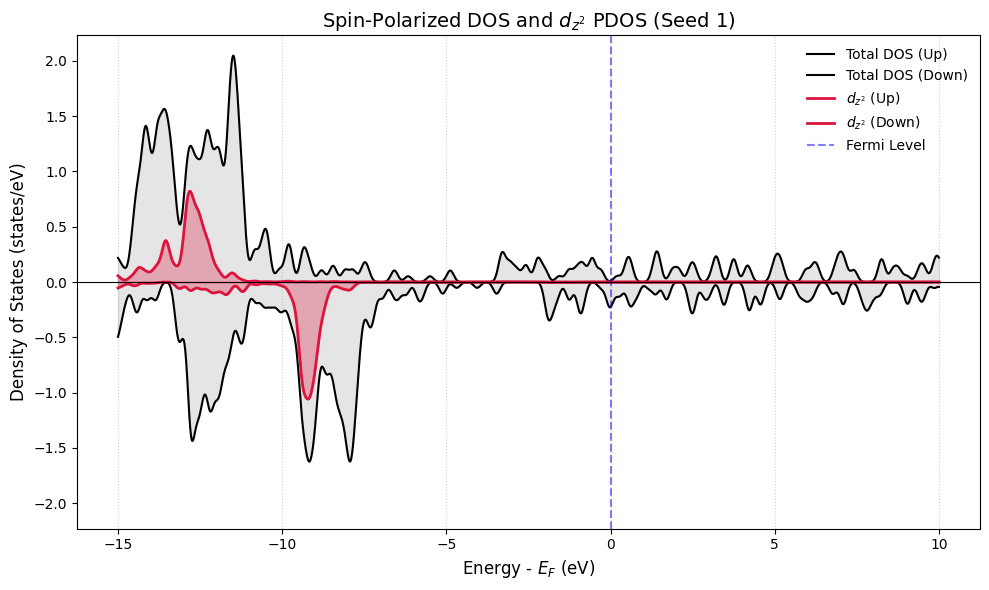

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_dos_from_csv(csv_file, seed=0):
    # 1. Load the data
    df = pd.read_csv(csv_file)
    
    # 2. Extract column names dynamically based on the seed
    # (Matches the naming convention from our previous DOS script)
    energy_col = f'energy_{seed}'
    total_up = f'spin_up_{seed}'
    total_down = f'spin_down_{seed}'
    
    # Look for any dz2 columns (there might be multiple if you have multiple Fe atoms)
    dz2_cols_up = [c for c in df.columns if f'dz2_atom' in c and f'up_{seed}' in c]
    dz2_cols_down = [c for c in df.columns if f'dz2_atom' in c and f'down_{seed}' in c]

    # 3. Create the plot
    plt.figure(figsize=(10, 6))
    
    # Plot Total DOS
    # We multiply 'down' values by -1 to create the mirrored effect
    plt.plot(df[energy_col], df[total_up], color='black', lw=1.5, label='Total DOS (Up)')
    plt.plot(df[energy_col], -df[total_down], color='black', lw=1.5, label='Total DOS (Down)')
    plt.fill_between(df[energy_col], df[total_up], color='gray', alpha=0.2)
    plt.fill_between(df[energy_col], -df[total_down], color='gray', alpha=0.2)

    # Plot PDOS (dz2)
    # If multiple atoms were saved, we sum them or plot them individually.
    # Here we sum them for a 'total dz2' contribution.
    if dz2_cols_up:
        sum_dz2_up = df[dz2_cols_up].sum(axis=1)
        sum_dz2_down = df[dz2_cols_down].sum(axis=1)
        
        plt.plot(df[energy_col], sum_dz2_up, color='crimson', lw=2, label=r'$d_{z^2}$ (Up)')
        plt.plot(df[energy_col], -sum_dz2_down, color='crimson', lw=2, label=r'$d_{z^2}$ (Down)')
        plt.fill_between(df[energy_col], sum_dz2_up, color='crimson', alpha=0.3)
        plt.fill_between(df[energy_col], -sum_dz2_down, color='crimson', alpha=0.3)

    # 4. Formatting
    plt.axvline(0, color='blue', linestyle='--', alpha=0.5, label='Fermi Level')
    plt.axhline(0, color='black', lw=0.8)
    
    plt.xlabel('Energy - $E_F$ (eV)', fontsize=12)
    plt.ylabel('Density of States (states/eV)', fontsize=12)
    plt.title(f'Spin-Polarized DOS and $d_{{z^2}}$ PDOS (Seed {seed})', fontsize=14)
    
    # Adjust y-axis to be symmetric
    y_limit = plt.gca().get_ylim()
    max_val = max(abs(y_limit[0]), abs(y_limit[1]))
    plt.ylim(-max_val, max_val)
    
    plt.legend(loc='upper right', frameon=False)
    plt.grid(axis='x', linestyle=':', alpha=0.6)
    plt.tight_layout()
    
    # Save and Show
    plt.savefig(f'dos_plot_seed_{seed}.png', dpi=300)
    plt.show()

# Run the plotting function
plot_dos_from_csv('dos_analysis.csv', seed=1)

# FePt and Fe3Pt

In a standard stoichiometric $\text{Fe}_3\text{Pt}$ system, Pt makes up 25% of the atoms ($r_{\text{Pt}} = 0.25$) and Fe makes up 75% ($r_{\text{Fe}} = 0.75$). To use your formula$$S = \frac{p-r}{1-r}$$uniformly across the whole supercell, we define:$p$: The total fraction of correctly occupied sites across the entire system.$r$: The overall baseline parameter for a completely disordered state. For a multi-sublattice system like $L1_2$, the baseline fraction of correctly occupied sites at random configuration is given by the sum of squares of the components: $r = (x_{\text{Fe}})^2 + (x_{\text{Pt}})^2 = 0.75^2 + 0.25^2 = 0.5625 + 0.0625 = 0.625$.

## bragg 

In [28]:
import random
import numpy as np

from ase.io import read, write
from ase.build import make_supercell

###############################################################################
# Function to calculate number of swaps for target S
###############################################################################

def number_of_swaps_for_S(total_atoms, S, r=0.5):
    """
    Long-range order parameter:
        S = (p - r) / (1 - r)
    
    Rearranged to solve for p (fraction of correctly occupied sites):
        p = S * (1 - r) + r

    wrong_sites = total_atoms * (1 - p)
    One anti-site swap creates TWO wrong sites.
    """

    # Calculate fraction of correct occupation 'p' using your formula
    p = S * (1.0 - r) + r

    # Calculate wrong sites based on p
    wrong_sites = int(round(total_atoms * (1.0 - p)))

    # Each swap fixes/breaks 2 sites (one Fe and one Pt)
    swaps = wrong_sites // 2

    return swaps

###############################################################################
# Apply anti-site defects
###############################################################################

def apply_order_parameter(reference_atoms, S, r_param=0.5, seed=1):

    random.seed(seed)

    atoms = reference_atoms.copy()

    symbols = atoms.get_chemical_symbols()

    total_atoms = len(atoms)

    swaps_needed = number_of_swaps_for_S(total_atoms, S, r=r_param)

    print("===================================")
    print(f"Target S = {S}")
    print(f"Required swaps = {swaps_needed}")

    ###########################################################################
    # Find atoms still occupying correct sites
    ###########################################################################

    fe_correct = []
    pt_correct = []

    for i in ideal_fe_sites:

        if symbols[i] == "Fe":
            fe_correct.append(i)

    for i in ideal_pt_sites:

        if symbols[i] == "Pt":
            pt_correct.append(i)

    swaps_needed = min(
        swaps_needed,
        len(fe_correct),
        len(pt_correct)
    )

    ###########################################################################
    # Randomly select atoms to swap
    ###########################################################################

    chosen_fe = random.sample(fe_correct, swaps_needed)
    chosen_pt = random.sample(pt_correct, swaps_needed)

    ###########################################################################
    # Introduce anti-site defects
    ###########################################################################

    for fe_i, pt_i in zip(chosen_fe, chosen_pt):

        symbols[fe_i] = "Pt"
        symbols[pt_i] = "Fe"

    atoms.set_chemical_symbols(symbols)

    ###########################################################################
    # Calculate actual S using the new formula
    ###########################################################################

    correct_sites = 0

    for i in ideal_fe_sites:

        if symbols[i] == "Fe":
            correct_sites += 1

    for i in ideal_pt_sites:

        if symbols[i] == "Pt":
            correct_sites += 1

    # p_actual is the actual fraction of correct sites
    p_actual = correct_sites / total_atoms

    # S = (p - r) / (1 - r)
    S_actual = (p_actual - r_param) / (1.0 - r_param)

    print(f"Actual S = {S_actual:.4f}")

    return atoms

###############################################################################
# 1. Read bulk FePt structure from CIF
###############################################################################

# Example:
# bulk_FePt.cif

atoms = read("Fe3Pt.cif") # FePt.cif

###############################################################################
# 2. Create supercell
###############################################################################

# Supercell size
P = np.diag([3, 3, 3])

supercell = make_supercell(atoms, P)

###############################################################################
# 3. Define ideal sublattices from the original ordered structure
###############################################################################

# In L10-FePt:
# one sublattice is Fe-rich
# the other is Pt-rich
#
# We determine the ideal sites directly from the CIF structure.

scaled = supercell.get_scaled_positions()
symbols = supercell.get_chemical_symbols()

###############################################################################
# 4. Identify Fe and Pt ideal sites
###############################################################################

ideal_fe_sites = []
ideal_pt_sites = []

for i, symbol in enumerate(symbols):

    if symbol == "Fe":
        ideal_fe_sites.append(i)

    elif symbol == "Pt":
        ideal_pt_sites.append(i)

###############################################################################
# 6. Generate structures for multiple S values
###############################################################################

S_values = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4]

r_alloy = 0.625 # 0.625 Fe3Pt; 0.5 FePt

for S in S_values:

    structure = apply_order_parameter(supercell, S, r_param=r_alloy, seed=2)

    # filename = f"FePt_S_{S:.1f}.xsf"
    filename = f"Fe3Pt_S_{S:.1f}.xsf"

    write(filename, structure)

    print(f"Saved: {filename}")

###############################################################################
# 7. Optional visualization
###############################################################################

# from ase.visualize import view
# view(structure)

Target S = 1.0
Required swaps = 0
Actual S = 1.0000
Saved: Fe3Pt_S_1.0.xsf
Target S = 0.9
Required swaps = 2
Actual S = 0.9012
Saved: Fe3Pt_S_0.9.xsf
Target S = 0.8
Required swaps = 4
Actual S = 0.8025
Saved: Fe3Pt_S_0.8.xsf
Target S = 0.7
Required swaps = 6
Actual S = 0.7037
Saved: Fe3Pt_S_0.7.xsf
Target S = 0.6
Required swaps = 8
Actual S = 0.6049
Saved: Fe3Pt_S_0.6.xsf
Target S = 0.5
Required swaps = 10
Actual S = 0.5062
Saved: Fe3Pt_S_0.5.xsf
Target S = 0.4
Required swaps = 12
Actual S = 0.4074
Saved: Fe3Pt_S_0.4.xsf


In [ ]:
import numpy as np
from ase import Atoms
from ase.io import write
from ase.data import covalent_radii

from pathlib import Path
from datetime import datetime

import random

from agox.generators.ABC_generator import GeneratorBaseClass


class DisorderGenerator(GeneratorBaseClass):

    name = "DisorderGenerator"
    def __init__(
        self,
        contiguous=False,
        attempts=100,
        may_nucleate_at_several_places=None,
        replace=True,
        write_struct=True,
        output_dir="generated_structures",
        min_distance_scale=0.8,        
        print_result = False,

        reference_atoms = None, 
        S = 0.9, 
        r_param=0.5, #FePt 0.5, Fe3Pt 0.625
        seed=1

        
        # a=3.161058820599375,
        # cell=None,
        # frac_positions=None,

        # elements=(
        #     ["Fe"] * 6 +
        #     ["Co"] * 6 +
        #     ["Ni"] * 6 +
        #     ["Cu"] * 4 +
        #     ["Pt"] * 10
        # ),

        # json_path=None,
        **kwargs
    ):
        super().__init__(replace=replace, **kwargs)
        self.contiguous = contiguous
        self.attempts = attempts
        self.write_struct = write_struct
        self.output_dir = Path(output_dir)
        self.run_dir = self._create_new_run_dir() if write_struct else None
        self.min_distance_scale = min_distance_scale
        self.print_result = print_result
        if may_nucleate_at_several_places is not None:
            DeprecationWarning(
                "'may_nucleate_at_several_places' is deprecated and will be removed. "
                "Use 'contiguous' instead."
            )
            self.contiguous = not may_nucleate_at_several_places

        self.seed = seed
        self.reference_atoms = reference_atoms
        self.S = S
        self.r_param=r_param

    def check_too_close(self, atoms, scale=None):
        """
        Check whether any atom pair is too close.

        Uses covalent radii and periodic boundary conditions.

        Parameters
        ----------
        atoms : ASE Atoms
            Structure to check.

        scale : float
            Multiplication factor for covalent radii sum.
            If None, uses self.min_distance_scale.

        Returns
        -------
        bool
            True if atoms are too close.
        """

        if scale is None:
            scale = self.min_distance_scale

        numbers = atoms.get_atomic_numbers()

        # Distance matrix using minimum image convention
        dmat = atoms.get_all_distances(mic=True)

        # Ignore self-distances
        np.fill_diagonal(dmat, np.inf)

        for i in range(len(atoms)):
            for j in range(i + 1, len(atoms)):

                cutoff = scale * (
                    covalent_radii[numbers[i]] +
                    covalent_radii[numbers[j]]
                )

                if dmat[i, j] < cutoff:
                    return True

        return False

## run

In [12]:
import os
import numpy as np

from ase import Atoms
from ase.build import bulk
from ase.io import write, read

# package untuk ML
from agox import AGOX
from agox.environments import Environment
from agox.generators import RattleGenerator
from agox.samplers import KMeansSampler, FixedSampler
from agox.collectors import ParallelCollector, StandardCollector
from agox.acquisitors import LowerConfidenceBoundAcquisitor
from agox.postprocessors import ParallelRelaxPostprocess
from agox.evaluators import LocalOptimizationEvaluator
from agox.databases import Database
from agox.models.descriptors.fingerprint import Fingerprint
from agox.models.GPR import GPR
from agox.models.GPR.kernels import RBF, Noise, Constant as C
from agox.models.GPR.priors import Repulsive
from agox.helpers import SubprocessGPAW

# costume generator; bragg generator
from scripts.bragg_generator import BraggGenerator

# addition untuk buat structure
from ase.build import bulk
from ase.build import make_supercell

############################ parameter
cif_file = "Fe3Pt.cif" # "FePt.cif" #"Fe3Pt.cif"
S_target = 1

# Opsi A: Tentukan nilai konstanta kisi baru [a, b, c, alpha, beta, gamma]
# Contoh: a=3.9, b=3.9, c=3.7, alpha=90, beta=90, gamma=90
new_lattice_params = [3.90, 3.90, 3.70, 90, 90, 90]

supercell = (3, 3, 3)

kpts = (1, 1, 1) 
ncores = 24 # 16 genkai

# param Agox
N_iterations = 100 # AGOX iterations
num_candidates = {0: [10, 0], 10: [5, 5]} # control generator
sample_size = 10

############################

# input structure reference
atoms = read(cif_file)

# edit lattice parameter
atoms.set_cell(new_lattice_params, scale_atoms=True)

# edit supercell
P = np.diag(supercell)
atoms = make_supercell(atoms, P)

success_count = 0
fail_count = 0

for seed in range(100):
    print(f"Start seed: {seed}")   

    path_result = f"seed_{seed}/0_result"
    path_xsf = f"{path_result}/0_xsf"
    path_fig = f"{path_result}/1_fig"
    db_dir = f"seed_{seed}/1_db"

    for d in [path_xsf, path_fig, db_dir]:
        os.makedirs(d, exist_ok=True)

    # environment
    template = Atoms("", cell=atoms.cell.copy(), pbc=True)
    environment = Environment(
        template=template,
        symbols=atoms.get_chemical_formula(),
        confinement_cell=template.cell.copy(),
        confinement_corner=np.array([0, 0, 0]),
        box_constraint_pbc=[True, True, True],
    )    

    n_rattle = len(atoms)
    generators = [
        BraggGenerator(
        **environment.get_confinement(),
        atoms_template = atoms,
        S_target = S_target, # 1.0,
        # S_options=None,
        # seed=2,
        randomize_seed=True,
        write_struct=True,
        output_dir="generated_structures",
        min_distance_scale=0.7,
        print_result=False,
        replace=True
        ),
        
        RattleGenerator(
            **environment.get_confinement(),
            n_rattle=int(n_rattle), # 0.7 * n_rattle
            rattle_amplitude=0.3 #2.3,
        ),
        # PermutationGenerator(
        #     **environment.get_confinement(),
        #     max_number_of_swaps=n_atoms,
        #     rattle_strength=0.3,
        #     use_xy_only=False,
        #     ignore_H=False,
        #     write_candidates_to_disk=False,
        #     replace=True,
        # )
    ]

    # test generate structure
    try:
            bragg_candidate = generators[0](
                sampler=None,
                environment=environment
            )[0]
            write(f"{path_xsf}/bragg_candidate_{seed}.xsf", bragg_candidate)
            print(f"bragg {seed}")
        
            sampler_test = FixedSampler(bragg_candidate)
        
            rattle_candidate = generators[1](
                sampler_test,
                environment
            )[0]
            write(f"{path_xsf}/rattle_candidate_{seed}.xsf", rattle_candidate)
            print(f"rattle {seed}")
        
            # permut_candidate = generators[2](
            #     sampler_test,
            #     environment
            # )[0]
            # write(f"{path_xsf}/permut_candidate_{seed}.xsf", permut_candidate)
            # print(f"permut {seed}")
            success_count += 1
    except Exception:
            fail_count += 1

    print(f"Current: {success_count=}, {fail_count=}")

    database = Database(filename=f"{db_dir}/db_{seed}.db", order=5)
    descriptor = Fingerprint(environment=environment)  

    beta = 0.01
    k0 = C(beta, (beta, beta)) * RBF()
    k1 = C(1 - beta, (1 - beta, 1 - beta)) * RBF()
    kernel = C(5000, (1, 1e5)) * (k0 + k1) + Noise(0.01, (0.01, 0.01))

    model = GPR(
        descriptor=descriptor,
        kernel=kernel,
        database=database,
        prior=Repulsive(),
        # use_ray = False
    )

    sampler = KMeansSampler(
        descriptor=descriptor,
        database=database,
        sample_size=sample_size,
    )

    collector = ParallelCollector(
        generators=generators,
        sampler=sampler,
        environment=environment,
        num_candidates=num_candidates,
        order=1,
    )

    """
    collector = StandardCollector(
        generators=generators,
        sampler=sampler,
        environment=environment,
        num_candidates=num_candidates,
        order=1,
    )	
    """

    acquisitor = LowerConfidenceBoundAcquisitor(model=model, kappa=2, order=3)

    relaxer = ParallelRelaxPostprocess(
        model=acquisitor.get_acquisition_calculator(),
        constraints=environment.get_constraints(),
        optimizer_run_kwargs={"steps": 100},
        start_relax=10,
        order=2,
    )

    calc = SubprocessGPAW(
        ncores=ncores,
        mode={"name": "lcao"},
        basis="dzp",
        xc="PBE",
        kpts=kpts,
        symmetry="off",
        nbands="nao",
        mixer={"backend": "pulay", "beta": 0.05, "nmaxold": 5, "weight": 100},
        convergence={"energy": 1e-4, "density": 1e-3, "eigenstates": 1e-3},
        occupations={"name": "fermi-dirac", "width": 0.05},
        maxiter=100,
        txt="output.txt",
    )

    evaluator = LocalOptimizationEvaluator(
        calc,
        gets={"get_key": "prioritized_candidates"},
        optimizer_kwargs={"logfile": None},
        optimizer_run_kwargs={"fmax": 0.05, "steps": 1},
        constraints=environment.get_constraints(),
        order=4,
    )

    agox = AGOX(
        collector,
        relaxer,
        acquisitor,
        evaluator,
        database,
        seed=seed,
    )

    agox.run(N_iterations=N_iterations)
    

Start seed: 0


╭───────────────────────────── Environment report ─────────────────────────────╮
│ Atoms in search:                                                             │
│     Fe = 81                                                                  │
│     Pt = 27                                                                  │
│ Template formula:                                                            │
│ Full formula: Fe81Pt27                                                       │
│ Cell:                                                                        │
│     11.70 0.00 0.00                                                          │
│     0.00 11.70 0.00                                                          │
│     0.00 0.00 11.10                                                          │
│ Periodicity:                                                                 │
│     True True True                                                           │
│ Box constraint: True                                                         │
│ Confinement corner                                                           │
│     0.00 0.00 0.00                                                           │
│ Confinement cell:                                                            │
│     11.70 0.00 0.00                                                          │
│     0.00 11.70 0.00                                                          │
│     0.00 0.00 11.10                                                          │
╰──────────────────────────────────────────────────────────────────────────────╯

Ordered structures tracking directory: generated_structures/run_ordered_20260607_171107
bragg 0
rattle 0
Current: success_count=1, fail_count=0
GPR: Attaching to database: <agox.databases.database.Database object at 0x14d94335a190>
SamplerKMeans: Attaching to database: <agox.databases.database.Database object at 0x14d94335a190>


Numpy random seed: 0

Modules in pool

...

Number of candidates this iteration: 5

───────────────────────────────── PoolRelaxer ──────────────────────────────────

(Actor pid=41064) Traceback (most recent call last):
(Actor pid=41064)   File "/home/asyamsul24/miniconda3/envs/agox_gofee/lib/python3.11/site-packages/agox/postprocessors/ray_relax/remote_relax.py", line 83, in remote_relax
(Actor pid=41064)     initial_energy = _candidate.get_potential_energy()
(Actor pid=41064)                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
(Actor pid=41064)   File "/home/asyamsul24/miniconda3/envs/agox_gofee/lib/python3.11/site-packages/ase/atoms.py", line 772, in get_potential_energy
(Actor pid=41064)     energy = self._calc.get_potential_energy(self)
(Actor pid=41064)              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
(Actor pid=41064)   File "/home/asyamsul24/miniconda3/envs/agox_gofee/lib/python3.11/site-packages/ase/calculators/abc.py", line 26, in get_potential_energy
(Actor pid=41064)     return self.get_property(name, atoms)
(Actor pid=41064)            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
(Actor pid=41064)   File "/home/asyamsul24/miniconda3/envs/agox_go

RayTaskError(AttributeError): [36mray::Actor.execute_function()[39m (pid=41001, ip=192.168.3.42, actor_id=be35c2a43c6e43d00e96911401000000, repr=<agox.utils.ray.actor.Actor object at 0x151788c63910>)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/asyamsul24/miniconda3/envs/agox_gofee/lib/python3.11/site-packages/agox/utils/ray/actor.py", line 43, in execute_function
    return fn(*[self.modules[key] for key in module_keys], *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/asyamsul24/miniconda3/envs/agox_gofee/lib/python3.11/site-packages/agox/postprocessors/ray_relax/remote_relax.py", line 98, in remote_relax
    forces = _candidate.get_forces()
             ^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/asyamsul24/miniconda3/envs/agox_gofee/lib/python3.11/site-packages/ase/atoms.py", line 829, in get_forces
    forces = self._calc.get_forces(self)
             ^^^^^^^^^^^^^^^^^

2026-06-07 17:14:42,506	ERROR worker.py:438 -- Unhandled error (suppress with 'RAY_IGNORE_UNHANDLED_ERRORS=1'): ray::Actor.execute_function() (pid=41075, ip=192.168.3.42, actor_id=a4bd4f4d014f1797558ae86501000000, repr=<agox.utils.ray.actor.Actor object at 0x1476ede578d0>)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/asyamsul24/miniconda3/envs/agox_gofee/lib/python3.11/site-packages/agox/utils/ray/actor.py", line 43, in execute_function
    return fn(*[self.modules[key] for key in module_keys], *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/asyamsul24/miniconda3/envs/agox_gofee/lib/python3.11/site-packages/agox/postprocessors/ray_relax/remote_relax.py", line 98, in remote_relax
    forces = _candidate.get_forces()
             ^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/asyamsul24/miniconda3/envs/agox_gofee/lib/python3.11/site-packages/ase/atoms.py", line 829, in get_forces

# Trash

In [ ]:
import os
import re
import numpy as np
from ase import Atoms
from ase.build import bulk, surface
from ase.constraints import FixAtoms
from ase.io import read, write

from agox import AGOX
from agox.acquisitors import LowerConfidenceBoundAcquisitor
from agox.collectors import ParallelCollector, StandardCollector
from agox.databases import Database
from agox.environments import Environment
from agox.evaluators import LocalOptimizationEvaluator
from agox.generators import RattleGenerator
from agox.helpers import SubprocessGPAW
from agox.models.descriptors.fingerprint import Fingerprint
from agox.models.GPR import GPR
from agox.models.GPR.kernels import RBF, Noise, Constant as C
from agox.models.GPR.priors import Repulsive
from agox.postprocessors import ParallelRelaxPostprocess, RelaxPostprocess
from agox.samplers import FixedSampler, KMeansSampler

# Custom project scripts for stacking, structural modification, and plotting
from scripts.add_adsorbate_to_hollows import add_adsorbate_to_hollows
from scripts.build_fe_stack import build_fe_stack
from scripts.build_heteroStruct import build_heteroStruct
from scripts.build_mgo_stack import build_mgo_stack
from scripts.hetero_struct_randomize import HeteroStructRandomize
from scripts.plot_structure import plot_structure
from scripts.remove_random_atoms_by_species import remove_random_atoms_by_species


# =====================================================================
# 1. Global Simulation & Lattice Parameter Tuning
# =====================================================================
vacuum = 20
a_mgo = 4.212
a_fe = 2.870190                     # Fe optimized LCAO lattice constant (Å)
a_mgo_matched = a_mgo / np.sqrt(2)  # Coherent interfacial matching scaling factor
strain = (a_mgo_matched - a_fe) / a_fe * 100

dist_z_fe2o = 0.5                   # Experimental initial Fe-O vertical separation (Å)
ncores = 24                         # Parallel CPU core count allocation
supercell = (5, 5, 1)               # Lateral simulation slab repetition dimensions
kpts = (1, 1, 1)                    # Gamma-point Brillouin zone sampling

# =====================================================================
# 2. AGOX Active Learning Parameters
# =====================================================================
kappa = 2                           # Exploration/Exploitation balance parameter (LCB Acquisition)
N_iterations = 100                  # Maximum active learning iterations per run
sample_size = 20                    # Representative clustering pool size

mgo_layer_number = 1                # Total thickness of bottom MgO support (monolayers)
fe_layer_number = 1                 # Total thickness of top Fe film (monolayers)
confinement_cell_height_multiplyer = 4  # Scale height of non-periodic search domain

# Interpolate structural strain: 0.0 = Pure Fe, 1.0 = Fully coherent with MgO
interpolation_factor = 0
a_custom = a_fe + interpolation_factor * (a_mgo_matched - a_fe)

# Multi-stage candidate generator allocation mapping iteration steps
num_candidates = {
    0: [20, 0],   # Gen 1 (structural randomize) active, Gen 2 (rattle) inactive
    10: [10, 10],  # Mixed generation mode
    25: [0, 20]   # Solely apply rattle searches to near-equilibrium hulls
}

# =====================================================================
# 3. Alloy & Adsorbate Composition Modification
# =====================================================================
removed_num = 0       # Number of Fe atoms randomly pruned to simulate coverage/defects
symbol_add = 'B'      # Dopant/adsorbate atomic species
z_height_add = 0      # Vertical coordinate height offset relative to the base layer
num_atoms_add = 2     # Number of dopant/adsorbate atoms to insert into hollow sites

# =====================================================================
# 4. Multi-Seed Loop & Infrastructure Initialization
# =====================================================================
for seed in range(103):
    print(f"\n==================================================")
    print(f"Executing Global Optimization Sequence | Seed: {seed}")
    print(f"==================================================")
    
    # Path infrastructure mapping directory outputs
    path_result = f"seed_{seed}/0_result"
    path_xsf = f"{path_result}/0_xsf"
    path_fig = f"{path_result}/1_fig"
    db_dir = f"seed_{seed}/1_db"
    latt_log = f'{path_result}/latt_log.md'

    for d in [path_xsf, path_fig, db_dir]:
        os.makedirs(d, exist_ok=True)
        
    with open(latt_log, 'w') as f:
        f.write(f"{a_fe=}\n{a_mgo=}\n{a_mgo_matched=}\n{strain=:.2f}%\n")
        
    # --- Base Substrate Layer Definition ---
    bulk_mgo = bulk('MgO', 'rocksalt', a=a_mgo, cubic=True)
    slab_mgo = surface(bulk_mgo, (0, 0, 1), layers=1, vacuum=vacuum)

    # Compute step profile height distances within MgO layers
    z_positions = slab_mgo.get_positions()[:, 2]
    unique_z = np.unique(np.round(z_positions, 5))
    
    if len(unique_z) >= 2:
        unique_z.sort()
        dist_mgo = unique_z[1] - unique_z[0]
    else:
        dist_mgo = 2.106  # Empirical fallback default spacing
    
    # --- Thin Film and Heterostructure Assembly ---
    fe_bulk = bulk('Fe', 'bcc', a=a_custom, cubic=True)
    slab_fe_base = surface(fe_bulk, (0, 0, 1), layers=1, vacuum=vacuum)
    
    # Stack configurations
    slab_mgofe = build_mgo_stack(
        slab_fe_base, num_layers=mgo_layer_number, dist_mgo=dist_mgo, 
        vacuum=vacuum, output_path=f"{path_xsf}/slab_mgofe.xsf", rotate_system=False
    )
    slab_mgo = slab_mgofe[[atom.symbol != 'Fe' for atom in slab_mgofe]].repeat(supercell)
    slab_fe = build_fe_stack(
        slab_fe_base, num_layers=fe_layer_number, vacuum=vacuum, 
        output_path=f"{path_xsf}/slab_fe.xsf"
    ).repeat(supercell)
    
    slab_deposition = slab_fe.copy() 
    slab_substrate = slab_mgo.copy()
    
    # Apply chemical concentration modifications (atom removal)
    slab_deposition = remove_random_atoms_by_species(slab_deposition, 'Fe', removed_num)

    # Place and insert dopant species (e.g. Boron) into structural hollows
    slab_deposition = add_adsorbate_to_hollows(
        slab_deposition, symbol=symbol_add, height=z_height_add, 
        num_atoms=num_atoms_add, seed=seed
    )

    # Build the target interface and verify structure configurations
    test_hetero, _, _, _, _ = build_heteroStruct(
        slab_substrate, slab_deposition, output_path=f'{path_xsf}/heteroStruct.xsf'
    )

    # =====================================================================
    # 5. AGOX Search Environment Setup
    # =====================================================================
    slab_substrate.pbc = [True, True, False]
    confinement_corner = np.array([0, 0, slab_substrate.positions[:, 2].max() + dist_z_fe2o])
    
    # Build search box confinement constraints for structural modification
    z_pos = slab_deposition.get_positions()[:, 2]
    h_dep = max(z_pos.max() - z_pos.min(), 2.1)
    confinement_cell = slab_deposition.cell.copy()
    confinement_cell[2, 2] = h_dep * confinement_cell_height_multiplyer

    environment = Environment(
        template=slab_substrate,
        symbols=slab_deposition.get_chemical_formula(),
        confinement_cell=confinement_cell,
        confinement_corner=confinement_corner,
        box_constraint_pbc=[True, True, False]
    )
    
    # =====================================================================
    # 6. Candidate Generators Setup
    # =====================================================================
    n_rattle = len(slab_deposition)
    generators = [
        # Generator 0: Large-scale structural randomization
        HeteroStructRandomize(
            **environment.get_confinement(),
            slab_deposition=slab_deposition,
            hetero_slab_dist=dist_z_fe2o,
            rattle_amplitude=1.5,
            n_rattle=n_rattle,
            generate_pristine=False,
            write_struct=True,
        ),
        # Generator 1: Small-scale structural perturbation
        RattleGenerator(
            **environment.get_confinement(),
            n_rattle=int(n_rattle * 0.5),
            rattle_amplitude=2.3
        ),
    ]
    
    # Write initial validation/test structures to disk
    hetero_candidate = generators[0](sampler=None, environment=environment)[0]
    write(f'{path_xsf}/hetero_candidate.xsf', hetero_candidate)
    
    sampler_fixed = FixedSampler(hetero_candidate)
    rattle_candidate = generators[1](sampler_fixed, environment)[0]
    write(f'{path_xsf}/rattle_candidate.xsf', rattle_candidate)
    
    # =====================================================================
    # 7. Machine Learning & Model Pipeline (GPR + Fingerprint)
    # =====================================================================
    database = Database(filename=f"{db_dir}/db_{seed}.db", order=5)
    descriptor = Fingerprint(environment=environment)
    
    # Compound Gaussian Process Regression kernel definition
    beta = 0.01
    kernel = C(5000, (1, 1e5)) * (
        C(beta, (beta, beta)) * RBF() + C(1 - beta, (1 - beta, 1 - beta)) * RBF()
    ) + Noise(0.01, (0.01, 0.01))
    
    model = GPR(descriptor=descriptor, kernel=kernel, database=database, prior=Repulsive())
    
    # Sampler and Collector operations (parallelized configuration tracking)
    sampler_kmeans = KMeansSampler(descriptor=descriptor, database=database, sample_size=sample_size)
    collector = ParallelCollector(
        generators=generators,
        sampler=sampler_kmeans,
        environment=environment,
        num_candidates=num_candidates,
        order=1
    )
    
    # =====================================================================
    # 8. Optimization & Quantum Mechanical Evaluators (GPAW)
    # =====================================================================
    acquisitor = LowerConfidenceBoundAcquisitor(model=model, kappa=kappa, order=3)
    
    relaxer = ParallelRelaxPostprocess(
        model=acquisitor.get_acquisition_calculator(),
        constraints=environment.get_constraints(),
        optimizer_run_kwargs={"steps": 100},
        start_relax=10,
        order=2
    )
    
    # DFT Calculator backend settings
    calc = SubprocessGPAW(
        ncores=ncores,
        mode={"name": "lcao"},
        basis="dzp",
        xc="PBE",
        mixer={"backend": "pulay", "beta": 0.05, "nmaxold": 5, "weight": 100},
        convergence={"energy": 1e-4, "density": 1e-3, "eigenstates": 1e-3},
        txt=f"output_seed_{seed}.txt",
        kpts=kpts,
        symmetry='off',
        nbands='nao',
        maxiter=100,
        occupations={"name": "fermi-dirac", "width": 0.05},
        hund=True,
        spinpol=True
    )
    
    evaluator = LocalOptimizationEvaluator(
        calc,
        gets={"get_key": "prioritized_candidates"},
        optimizer_run_kwargs={"fmax": 0.05, "steps": 1},
        constraints=environment.get_constraints(),
        store_trajectory=False,
        order=4
    )
    
    # =====================================================================
    # 9. AGOX Active Learning Execution
    # =====================================================================
    agox = AGOX(collector, relaxer, acquisitor, evaluator, database, seed=seed)
    # agox.run(N_iterations=N_iterations)  # Uncomment to execute optimization loop

In [ ]:
import numpy as np
from ase.build import bulk

# Custom-made import from your environment
from scripts.add_B_concentration import add_B_concentration

# --- Configuration to test ---
a_ta = 3.331167              # Lattice parameter
supercell = (3, 3, 3)        # Change this to test larger/smaller structures
cB = 0.08                    # Boron concentration (e.g., 0.05 = 5%)
scale_cell = 1.00            # Cell scaling factor

print(f"Testing Concentration: {cB * 100}% | Supercell: {supercell}")
print("-" * 50)

# 1. Generate the pristine Tantalum bulk supercell
ta_bulk = bulk("Ta", "bcc", a=a_ta, cubic=True) * supercell
ta_bulk.set_cell(ta_bulk.cell * scale_cell, scale_atoms=True)

# 2. Add Boron using your custom script
tab_bulk, n_b, n_ta = add_B_concentration(
    ta_bulk, cB=cB, make_structure=True
)

# 3. Output the results
print(f"Number of Boron atoms (n_b):     {n_b}")
print(f"Number of Tantalum atoms (n_ta): {n_ta}")
print(f"Total atoms in cell:             {len(tab_bulk)}")
print(f"Actual calculated ratio:         {n_b / (n_b + n_ta) * 100:.2f}%")